# 1.2 Machine Learning - Naive Bayes und ANN

Dieses Notebook setzt die EDA in eine **reproduzierbare Machine-Learning-Pipeline** um. Der Aufbau orientiert sich an `Cypshu/AML_Project`: zentrale Konfiguration, reproduzierbare Splits, getrennte Train-/Validation-/Test-Phasen, Run-Artefakte, Checkpoints, Predictions-CSV, Metrik-Reporting und gespeicherte Plots.

Untersucht werden zwei Modellfamilien mit je einer Standard- und einer EDA-adaptierten Variante:

1. **Naive Bayes**: `GaussianNB` sowie Quantil-Normalisierung + abgestimmtes `var_smoothing`.
2. **ANN**: kleines klassisches MLP sowie ein problemangepasstes, regularisiertes und imbalance-aware MLP.

**Methodische Leitplanke:** Testdaten werden erst nach Training, Hyperparameterwahl, Threshold-Wahl und Validation-Ranking verwendet.

## 0. EDA -> Modellierungsentscheidungen

Die Varianten folgen direkt den Befunden aus `Cyp/EDA/01_Datensatz_Einfuehrung_final.ipynb`:

- rund 10 % positive Faelle -> **Average Precision / PR-AUC** ist zentral; Accuracy allein reicht nicht.
- 200 numerische Features und keine starke lineare Redundanz bei `|r| >= 0.8` -> GaussianNB ist als transparente probabilistische Baseline plausibel.
- viele kleine, stabile Einzeleffekte -> **alle Features** bleiben im Modell; keine vorgezogene label-informierte Featureselektion.
- geringe Varianzerklaerung durch wenige PCA-Komponenten -> kein PCA-Bottleneck im ANN.
- unterschiedliche Marginalverteilungen / Heavy-Tail- und Ausrei
ferdiagnostik -> die adaptierten Varianten testen train-only `QuantileTransformer(output_distribution='normal')`.
- starke Klassenimbalance -> das adaptierte ANN nutzt `BCEWithLogitsLoss(pos_weight=n_neg/n_pos)`; Thresholds werden nur auf Validation gewaehlt.

Die Quantiltransformation ist eine **zu testende Hypothese**, keine vorausgesetzte Verbesserung.

## 1. Pipeline-Uebersicht

1. Konfiguration, Seeds, Device und Run-Verzeichnis.
2. Datensatz laden und technische Checks wiederholen.
3. Erst splitten; danach Preprocessing nur auf Train fitten.
4. Standard- und EDA-adaptierte Varianten auf Train fitten; Tuning nur mit Validation.
5. Validation-Reporting und Modellwahl nach Average Precision.
6. Testset einmalig als finale Evaluation auswerten.
7. Resultate als Tabellen, Predictions, Checkpoints und Plots speichern.
8. Bootstrap-Konfidenzintervalle und optional ANN-Seed-Stabilitaet berichten.


## 2. Imports und zentrale Konfiguration

Zum technischen Testen kann die Umgebungsvariable `ADA_ML_SMOKE_TEST=1` gesetzt werden. Dann wird ein kleiner synthetischer Datensatz verwendet. Fuer die Abgabe muss der echte Santander-Datensatz verwendet werden.

In [1]:
from __future__ import annotations

import copy
import json
import logging
import os
import platform
import random
import sys
import time
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.datasets import make_classification
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    confusion_matrix, f1_score, log_loss, matthews_corrcoef,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
TARGET = "target"
DATA_FILENAME = "santander_customer_transaction_prediction.csv"
TEST_SIZE = 0.20
VAL_FRACTION_OF_DEV = 0.20  # -> 64% train, 16% validation, 20% test

BATCH_SIZE = 2048
EPOCHS_SMALL = 40
EPOCHS_ADAPTED = 60
PATIENCE_SMALL = 6
PATIENCE_ADAPTED = 8
LEARNING_RATE_SMALL = 1e-3
LEARNING_RATE_ADAPTED = 8e-4
WEIGHT_DECAY_ADAPTED = 1e-4

THRESHOLD_OBJECTIVE = "f1"
RUN_BOOTSTRAP = True
N_BOOTSTRAP = 200
RUN_ANN_SEED_STABILITY = False
ANN_STABILITY_SEEDS = (42, 43, 44)
SAVE_ARTIFACTS = True

SMOKE_TEST = os.getenv("ADA_ML_SMOKE_TEST", "0") == "1"
if SMOKE_TEST:
    EPOCHS_SMALL = 2
    EPOCHS_ADAPTED = 2
    PATIENCE_SMALL = 2
    PATIENCE_ADAPTED = 2
    BATCH_SIZE = 256
    N_BOOTSTRAP = 10
    RUN_ANN_SEED_STABILITY = False

EDA_LOGISTIC_REFERENCE = {
    "roc_auc": 0.8599,
    "average_precision": 0.5004,
    "balanced_accuracy_at_0_5": 0.7795,
    "recall_at_0_5": 0.7749,
    "precision_at_0_5": 0.2863,
    "f1_at_0_5": 0.4181,
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def resolve_cyp_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd / "Cyp"]
    candidates.extend(parent / "Cyp" for parent in cwd.parents)
    candidates.extend(cwd.parents)
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "EDA").exists() and (candidate / "data").exists():
            return candidate
    return cwd


CYP_ROOT = resolve_cyp_root()
ML_ROOT = CYP_ROOT / "ML"
RUNS_DIR = ML_ROOT / "runs"
run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = RUNS_DIR / f"{run_stamp}_NB_ANN"
PLOTS_DIR = RUN_DIR / "plots"
PREDICTIONS_DIR = RUN_DIR / "predictions"
CHECKPOINTS_DIR = RUN_DIR / "checkpoints"
HISTORIES_DIR = RUN_DIR / "histories"
MODELS_DIR = RUN_DIR / "models"

if SAVE_ARTIFACTS:
    for directory in [RUN_DIR, PLOTS_DIR, PREDICTIONS_DIR, CHECKPOINTS_DIR, HISTORIES_DIR, MODELS_DIR]:
        directory.mkdir(parents=True, exist_ok=True)

print("CYP_ROOT:", CYP_ROOT)
print("Run directory:", RUN_DIR)
print("Device:", DEVICE)
print("Smoke test:", SMOKE_TEST)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)


CYP_ROOT: C:\Users\Cypsa\Desktop\UNI\UNI JLU DS\ADA_Project\Cyp
Run directory: C:\Users\Cypsa\Desktop\UNI\UNI JLU DS\ADA_Project\Cyp\ML\runs\20260815_030409_NB_ANN
Device: cpu
Smoke test: False
Python: 3.12.3
pandas: 2.2.3
NumPy: 2.0.0
scikit-learn: 1.6.1
PyTorch: 2.12.0+cpu


## 3. Logging und Run-Artefakte

Analog zum AML-Projekt erzeugt jeder Lauf ein eigenes Verzeichnis unter `Cyp/ML/runs/` mit `train.log`, `config.json`, Split-Indizes, Predictions, Ergebnistabellen, ANN-Checkpoints, NB-Modelldateien, Epochenhistorien und Plot-Artefakten.

In [2]:
def setup_logger() -> logging.Logger:
    logger = logging.getLogger("ada_santander_ml")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    logger.propagate = False
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    stream = logging.StreamHandler(sys.stdout)
    stream.setFormatter(formatter)
    logger.addHandler(stream)
    if SAVE_ARTIFACTS:
        file_handler = logging.FileHandler(RUN_DIR / "train.log", encoding="utf-8")
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)
    return logger


LOGGER = setup_logger()
LOGGER.info("Experiment started on device=%s", DEVICE)


def save_figure(fig: plt.Figure, filename: str, dpi: int = 170) -> None:
    if SAVE_ARTIFACTS:
        fig.savefig(PLOTS_DIR / filename, dpi=dpi, bbox_inches="tight")


def save_json(payload: dict, path: Path) -> None:
    if SAVE_ARTIFACTS:
        with open(path, "w", encoding="utf-8") as handle:
            json.dump(payload, handle, indent=2, ensure_ascii=False)


2026-08-15 03:04:09,130 | INFO | Experiment started on device=cpu


## 4. Daten laden und technische Checks

Die EDA bleibt die fachliche Hauptanalyse. Hier werden nur die Checks wiederholt, die fuer eine reproduzierbare Modellpipeline notwendig sind.

,value
rows,200000.00000
features,200.00000
positive_share,0.10049
missing_cells_X,0.00000
non_finite_cells_X,0.00000
duplicate_rows_full,0.00000
constant_features,0.00000


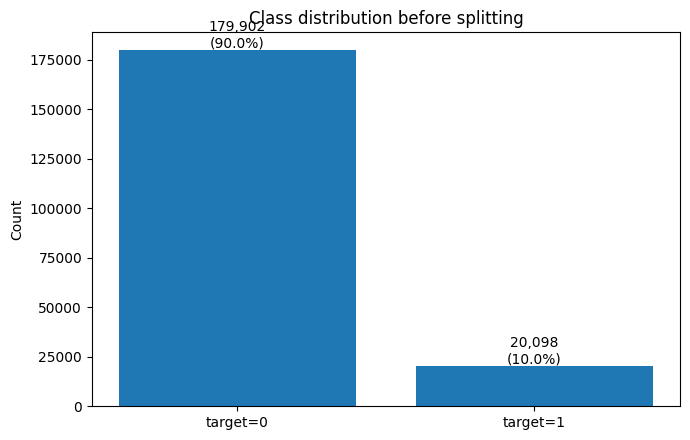

2026-08-15 03:04:40,949 | INFO | Loaded dataset rows=200000 features=200 positive_share=0.1005


In [3]:
def resolve_data_path() -> Path:
    candidates = [
        CYP_ROOT / "data" / DATA_FILENAME,
        Path.cwd() / "data" / DATA_FILENAME,
        Path.cwd() / "Cyp" / "data" / DATA_FILENAME,
        Path.cwd().parent / "data" / DATA_FILENAME,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Santander CSV not found. Expected e.g. Cyp/data/" + DATA_FILENAME)


if SMOKE_TEST:
    X_syn, y_syn = make_classification(
        n_samples=3000, n_features=20, n_informative=14, n_redundant=0,
        weights=[0.90, 0.10], class_sep=1.0, random_state=RANDOM_STATE,
    )
    feature_columns = [f"var_{i}" for i in range(X_syn.shape[1])]
    df = pd.DataFrame(X_syn, columns=feature_columns)
    df[TARGET] = y_syn.astype(int)
    DATA_PATH = Path("synthetic_smoke_test")
else:
    DATA_PATH = resolve_data_path()
    df = pd.read_csv(DATA_PATH)
    if TARGET not in df.columns:
        raise KeyError(f"Target column '{TARGET}' not found in {DATA_PATH}")
    feature_columns = [column for column in df.columns if column.startswith("var_")]
    if not feature_columns:
        feature_columns = [column for column in df.select_dtypes(include=[np.number]).columns if column != TARGET]

X = df[feature_columns].astype(np.float32)
y = df[TARGET].astype(int)
checks = pd.Series({
    "rows": len(df),
    "features": len(feature_columns),
    "positive_share": float(y.mean()),
    "missing_cells_X": int(X.isna().sum().sum()),
    "non_finite_cells_X": int((~np.isfinite(X.to_numpy())).sum()),
    "duplicate_rows_full": int(df.duplicated().sum()),
    "constant_features": int((X.nunique(dropna=False) <= 1).sum()),
})
display(checks.to_frame("value"))
if checks["missing_cells_X"] != 0 or checks["non_finite_cells_X"] != 0:
    raise ValueError("Unexpected missing or non-finite feature values detected.")
if y.nunique() != 2:
    raise ValueError(f"Expected binary target, found {y.nunique()} classes")

class_counts = y.value_counts().sort_index().rename(index={0: "target=0", 1: "target=1"})
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(class_counts.index, class_counts.values)
for idx, value in enumerate(class_counts.values):
    ax.text(idx, value, f"{value:,}\n({value / len(y):.1%})", ha="center", va="bottom")
ax.set_title("Class distribution before splitting")
ax.set_ylabel("Count")
fig.tight_layout()
save_figure(fig, "00_class_distribution.png")
plt.show()
LOGGER.info("Loaded dataset rows=%d features=%d positive_share=%.4f", len(df), len(feature_columns), y.mean())


## 5. Leakage-freier Split

Der erste Split reproduziert bewusst den 80:20-Testsplit aus der EDA (`random_state=42`, stratifiziert). Nur die 80 % Development-Daten werden weiter in Train und Validation geteilt. Ergebnis: 64 % Train, 16 % Validation, 20 % Test.

,split,n,share,positive_share
0,train,128000,0.64,0.10048
1,validation,32000,0.16,0.10050
2,test,40000,0.20,0.10050


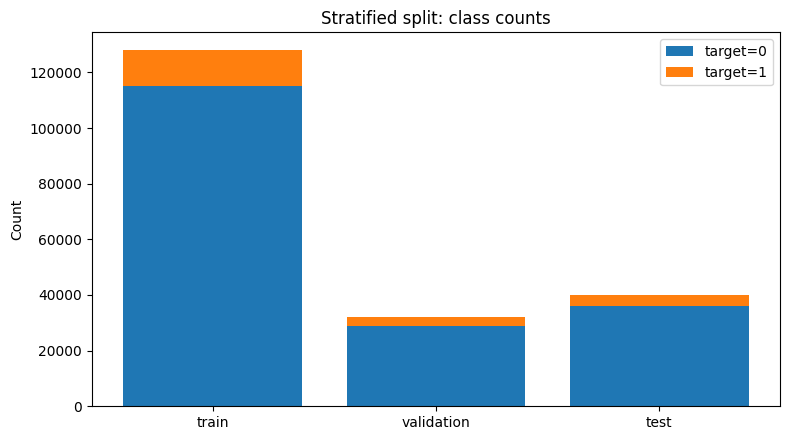

In [4]:
all_indices = np.arange(len(df))
y_array = y.to_numpy(dtype=np.int64)
idx_dev, idx_test = train_test_split(
    all_indices, test_size=TEST_SIZE, stratify=y_array, random_state=RANDOM_STATE,
)
idx_train, idx_val = train_test_split(
    idx_dev, test_size=VAL_FRACTION_OF_DEV, stratify=y_array[idx_dev], random_state=RANDOM_STATE,
)

X_train = X.iloc[idx_train].reset_index(drop=True)
X_val = X.iloc[idx_val].reset_index(drop=True)
X_test = X.iloc[idx_test].reset_index(drop=True)
y_train, y_val, y_test = y_array[idx_train], y_array[idx_val], y_array[idx_test]

split_report = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(idx_train), len(idx_val), len(idx_test)],
    "share": [len(idx_train)/len(df), len(idx_val)/len(df), len(idx_test)/len(df)],
    "positive_share": [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_report.round(5))

split_labels = np.full(len(df), "", dtype=object)
split_labels[idx_train] = "train"
split_labels[idx_val] = "validation"
split_labels[idx_test] = "test"
split_indices_df = pd.DataFrame({"row_index": all_indices, "split": split_labels})
if SAVE_ARTIFACTS:
    split_indices_df.to_csv(RUN_DIR / "split_indices.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(3)
negative_counts = [int((arr == 0).sum()) for arr in [y_train, y_val, y_test]]
positive_counts = [int((arr == 1).sum()) for arr in [y_train, y_val, y_test]]
ax.bar(x_pos, negative_counts, label="target=0")
ax.bar(x_pos, positive_counts, bottom=negative_counts, label="target=1")
ax.set_xticks(x_pos, ["train", "validation", "test"])
ax.set_title("Stratified split: class counts")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
save_figure(fig, "01_split_class_counts.png")
plt.show()


## 6. Einheitliches Reporting

Schwellenwertunabhaengig: ROC-AUC, Average Precision, Brier Score, Log Loss. Schwellenwertabhaengig: Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, Specificity und TN/FP/FN/TP. Jedes Modell wird bei `0.5` und beim auf Validation F1-optimalen Threshold berichtet.

In [5]:
def compute_metrics(y_true: np.ndarray, probabilities: np.ndarray, threshold: float) -> dict[str, float]:
    probabilities = np.asarray(probabilities, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")
    clipped = np.clip(probabilities, 1e-7, 1 - 1e-7)
    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "average_precision": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
        "log_loss": float(log_loss(y_true, clipped, labels=[0, 1])),
        "accuracy": float((predictions == y_true).mean()),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, predictions)),
        "specificity": float(specificity),
        "predicted_positive_share": float(predictions.mean()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def select_f1_threshold(y_true: np.ndarray, probabilities: np.ndarray):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if len(thresholds) == 0:
        return 0.5, pd.DataFrame()
    precision_t, recall_t = precision[:-1], recall[:-1]
    denom = precision_t + recall_t
    f1 = np.divide(2 * precision_t * recall_t, denom, out=np.zeros_like(denom), where=denom > 0)
    best_idx = int(np.nanargmax(f1))
    table = pd.DataFrame({"threshold": thresholds, "precision": precision_t, "recall": recall_t, "f1": f1})
    return float(thresholds[best_idx]), table


def prediction_frame(row_indices, y_true, probabilities, tuned_threshold):
    probabilities = np.asarray(probabilities, dtype=float)
    return pd.DataFrame({
        "row_index": row_indices,
        "true_label": np.asarray(y_true, dtype=int),
        "probability_target_1": probabilities,
        "prediction_at_0_5": (probabilities >= 0.5).astype(int),
        "prediction_at_tuned_threshold": (probabilities >= tuned_threshold).astype(int),
        "tuned_threshold": tuned_threshold,
    })

VAL_PROBS, TEST_PROBS, THRESHOLDS, THRESHOLD_CURVES, MODEL_META, HISTORIES = {}, {}, {}, {}, {}, {}
MODEL_ORDER = ["NB | standard", "NB | EDA-adapted", "ANN | small", "ANN | EDA-adapted"]


# 7. Naive Bayes

## 7.1 Standard: GaussianNB

Die Standardvariante nutzt alle Features unveraendert. GaussianNB modelliert pro Klasse und Feature eine Normalverteilung und kombiniert die Feature-Likelihoods unter einer bedingten Unabhaengigkeitsannahme. Diese Annahme ist stark, aber die EDA zeigt zumindest keine starke paarweise lineare Redundanz; als transparente Baseline ist das Modell daher sinnvoll.

In [6]:
name = "NB | standard"
start = time.perf_counter()
nb_standard = GaussianNB()
nb_standard.fit(X_train, y_train)
fit_seconds = time.perf_counter() - start
val_prob = nb_standard.predict_proba(X_val)[:, 1]
threshold, threshold_curve = select_f1_threshold(y_val, val_prob)

VAL_PROBS[name] = val_prob
THRESHOLDS[name] = threshold
THRESHOLD_CURVES[name] = threshold_curve
MODEL_META[name] = {
    "family": "Naive Bayes",
    "variant": "standard",
    "preprocessing": "raw features",
    "model": "GaussianNB(default)",
    "imbalance_training": "empirical class priors; no resampling",
    "selection_metric": "none",
    "fit_seconds": fit_seconds,
}
print(f"Validation F1-optimal threshold: {threshold:.5f}")
display(pd.Series(compute_metrics(y_val, val_prob, threshold)).to_frame("validation"))
if SAVE_ARTIFACTS:
    joblib.dump(nb_standard, MODELS_DIR / "gaussian_nb_standard.joblib")
LOGGER.info("%s fitted in %.2fs threshold=%.5f", name, fit_seconds, threshold)


Validation F1-optimal threshold: 0.26833


,validation
threshold,0.268334
roc_auc,0.887568
average_precision,0.580520
brier_score,0.060644
log_loss,0.211488
accuracy,0.905031
balanced_accuracy,0.760082
precision,0.524965
recall,0.578669
f1,0.550510


2026-08-15 03:04:44,283 | INFO | NB | standard fitted in 0.64s threshold=0.26833


## 7.2 EDA-adaptiert: Quantil-Normalisierung + GaussianNB

Die EDA zeigt unterschiedliche Schiefe, Kurtosis und Extremwertmuster. Die angepasste Variante testet deshalb `QuantileTransformer(output_distribution='normal')`, ausschliesslich auf Train gefittet. Anschliessend wird `var_smoothing` anhand der **Validation Average Precision** gewaehlt. Die Transformation ist nichtlinear und daher keine automatisch bessere Loesung, sondern eine explizite EDA-Hypothese.

Best var_smoothing: 1.0e-12
Validation F1-optimal threshold: 0.26614


,var_smoothing,validation_average_precision,validation_roc_auc,validation_brier
0,0.000000,0.579652,0.889116,0.060605
1,0.000000,0.579652,0.889116,0.060605
2,0.000000,0.579652,0.889116,0.060605
3,0.000000,0.579652,0.889116,0.060605
4,0.000000,0.579652,0.889116,0.060605
5,0.000000,0.579652,0.889116,0.060605
6,0.000001,0.579652,0.889116,0.060605


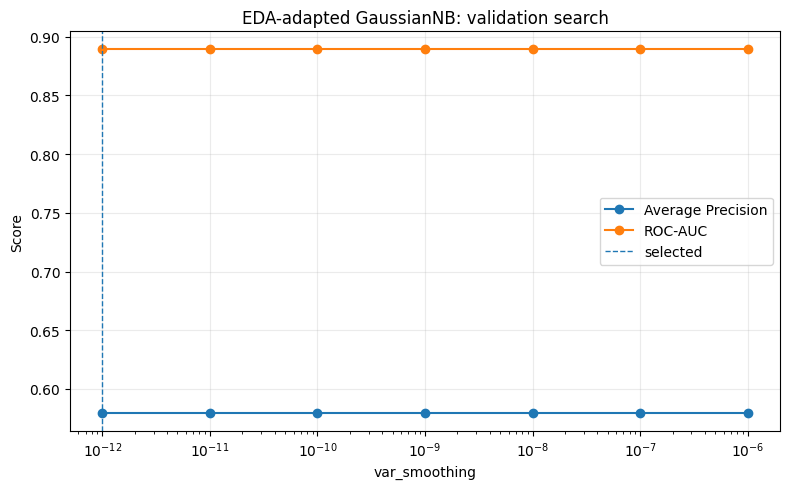

2026-08-15 03:05:03,793 | INFO | NB | EDA-adapted selected var_smoothing=1.00e-12 threshold=0.26614


In [7]:
quantile_transformer = QuantileTransformer(
    n_quantiles=min(1000, len(X_train)),
    output_distribution="normal",
    subsample=min(50_000, len(X_train)),
    random_state=RANDOM_STATE,
    copy=True,
)
start = time.perf_counter()
X_train_quantile = quantile_transformer.fit_transform(X_train).astype(np.float32)
X_val_quantile = quantile_transformer.transform(X_val).astype(np.float32)
transform_seconds = time.perf_counter() - start

smoothing_grid = np.logspace(-12, -6, 7)
nb_search_rows, nb_candidates = [], {}
for smoothing in smoothing_grid:
    candidate = GaussianNB(var_smoothing=float(smoothing))
    candidate.fit(X_train_quantile, y_train)
    probability = candidate.predict_proba(X_val_quantile)[:, 1]
    nb_search_rows.append({
        "var_smoothing": float(smoothing),
        "validation_average_precision": average_precision_score(y_val, probability),
        "validation_roc_auc": roc_auc_score(y_val, probability),
        "validation_brier": brier_score_loss(y_val, probability),
    })
    nb_candidates[float(smoothing)] = candidate

nb_search = pd.DataFrame(nb_search_rows).sort_values("validation_average_precision", ascending=False)
best_smoothing = float(nb_search.iloc[0]["var_smoothing"])
nb_adapted = nb_candidates[best_smoothing]
val_prob = nb_adapted.predict_proba(X_val_quantile)[:, 1]
threshold, threshold_curve = select_f1_threshold(y_val, val_prob)
name = "NB | EDA-adapted"
VAL_PROBS[name] = val_prob
THRESHOLDS[name] = threshold
THRESHOLD_CURVES[name] = threshold_curve
MODEL_META[name] = {
    "family": "Naive Bayes",
    "variant": "EDA-adapted",
    "preprocessing": "QuantileTransformer(normal), train-only",
    "model": f"GaussianNB(var_smoothing={best_smoothing:.1e})",
    "imbalance_training": "empirical priors; threshold tuned on validation",
    "selection_metric": "validation average precision",
    "transform_seconds": transform_seconds,
}
print("Best var_smoothing:", f"{best_smoothing:.1e}")
print("Validation F1-optimal threshold:", f"{threshold:.5f}")
display(nb_search.round(6))

search_plot = nb_search.sort_values("var_smoothing")
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(search_plot["var_smoothing"], search_plot["validation_average_precision"], marker="o", label="Average Precision")
ax.semilogx(search_plot["var_smoothing"], search_plot["validation_roc_auc"], marker="o", label="ROC-AUC")
ax.axvline(best_smoothing, linestyle="--", linewidth=1, label="selected")
ax.set_title("EDA-adapted GaussianNB: validation search")
ax.set_xlabel("var_smoothing")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "02_nb_var_smoothing_search.png")
plt.show()

if SAVE_ARTIFACTS:
    joblib.dump({"transformer": quantile_transformer, "model": nb_adapted, "best_smoothing": best_smoothing}, MODELS_DIR / "gaussian_nb_eda_adapted.joblib")
LOGGER.info("%s selected var_smoothing=%.2e threshold=%.5f", name, best_smoothing, threshold)


## 7.3 NB-Validation: direkte Gegenueberstellung

ROC/PR beurteilen das Ranking unabhaengig vom Betriebs-Threshold; die Threshold-Metriken werden zusaetzlich tabellarisch berichtet.

,threshold,roc_auc,average_precision,brier_score,log_loss,accuracy,balanced_accuracy,precision,recall,f1,mcc,specificity,predicted_positive_share,tn,fp,fn,tp
model,,,,,,,,,,,,,,,,,
NB | standard,0.26833,0.88757,0.58052,0.06064,0.21149,0.90503,0.76008,0.52496,0.57867,0.55051,0.4983,0.94150,0.11078,27100,1684,1355,1861
NB | EDA-adapted,0.26614,0.88912,0.57965,0.06061,0.21098,0.90700,0.76104,0.53448,0.57836,0.55556,0.5042,0.94372,0.10875,27164,1620,1356,1860


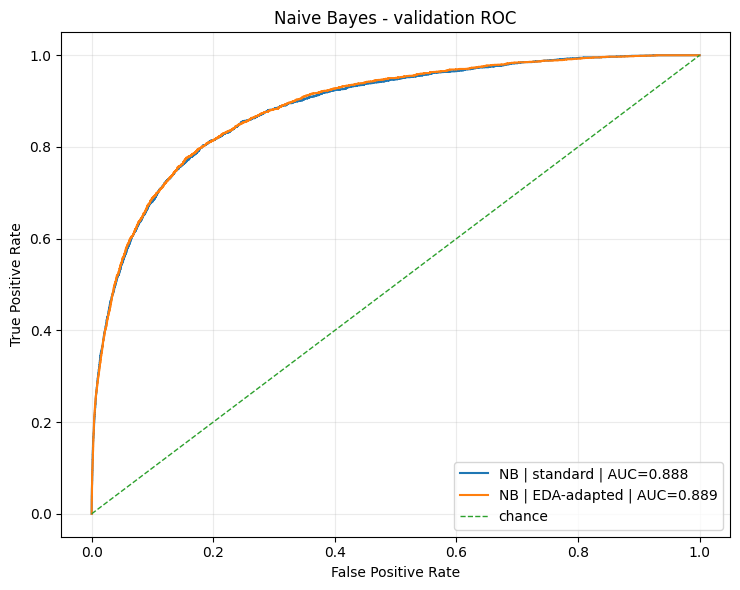

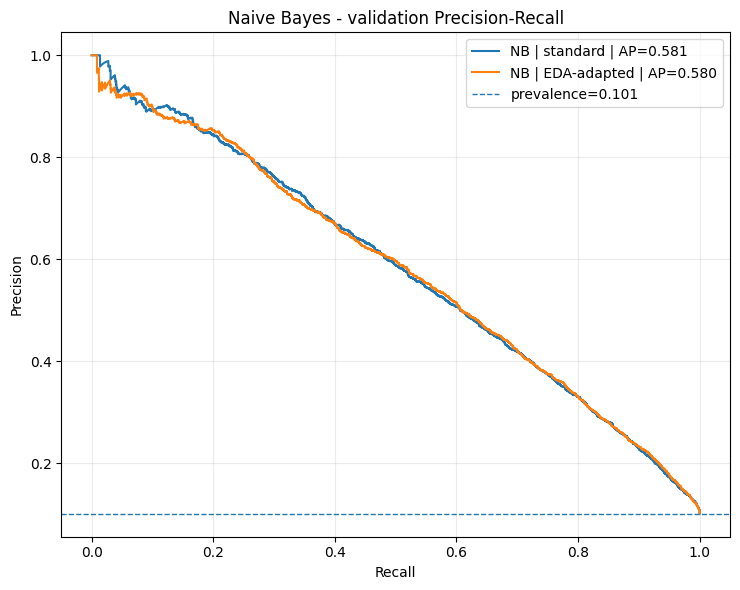

In [8]:
nb_val_rows = []
for model_name in ["NB | standard", "NB | EDA-adapted"]:
    nb_val_rows.append({"model": model_name, **compute_metrics(y_val, VAL_PROBS[model_name], THRESHOLDS[model_name])})
nb_val_table = pd.DataFrame(nb_val_rows).set_index("model")
display(nb_val_table.round(5))

fig, ax = plt.subplots(figsize=(7.5, 6))
for model_name in ["NB | standard", "NB | EDA-adapted"]:
    fpr, tpr, _ = roc_curve(y_val, VAL_PROBS[model_name])
    auc_value = roc_auc_score(y_val, VAL_PROBS[model_name])
    ax.plot(fpr, tpr, label=f"{model_name} | AUC={auc_value:.3f}")
ax.plot([0, 1], [0, 1], "--", linewidth=1, label="chance")
ax.set_title("Naive Bayes - validation ROC")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
save_figure(fig, "03_nb_validation_roc.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for model_name in ["NB | standard", "NB | EDA-adapted"]:
    precision, recall, _ = precision_recall_curve(y_val, VAL_PROBS[model_name])
    ap = average_precision_score(y_val, VAL_PROBS[model_name])
    ax.plot(recall, precision, label=f"{model_name} | AP={ap:.3f}")
ax.axhline(y_val.mean(), linestyle="--", linewidth=1, label=f"prevalence={y_val.mean():.3f}")
ax.set_title("Naive Bayes - validation Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
save_figure(fig, "04_nb_validation_pr.png")
plt.show()


# 8. Artificial Neural Networks

## 8.1 Preprocessing

- **Small ANN:** `StandardScaler`, nur auf Train gefittet.
- **EDA-adaptiertes ANN:** dieselbe train-only Quantil-Normalisierung wie beim adaptierten GaussianNB.

Es wird bewusst **keine PCA und keine label-informierte Featureselektion** verwendet.

In [9]:
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train).astype(np.float32)
X_val_standard = standard_scaler.transform(X_val).astype(np.float32)
X_train_adapted = X_train_quantile
X_val_adapted = X_val_quantile
if SAVE_ARTIFACTS:
    joblib.dump(standard_scaler, MODELS_DIR / "ann_small_standard_scaler.joblib")
    joblib.dump(quantile_transformer, MODELS_DIR / "ann_adapted_quantile_transformer.joblib")
print("Small ANN train matrix:", X_train_standard.shape, X_train_standard.dtype)
print("Adapted ANN train matrix:", X_train_adapted.shape, X_train_adapted.dtype)


Small ANN train matrix: (128000, 200) float32
Adapted ANN train matrix: (128000, 200) float32


## 8.2 Architekturen

`SmallANN`: `input -> 64 -> 32 -> 1`, ReLU.  
`EDAAdaptedANN`: `input -> 128 -> 64 -> 32 -> 1`, BatchNorm, Dropout und ReLU.

Die angepasste Architektur bleibt absichtlich moderat: Die EDA begruendet viele schwache Signale, aber kein extrem tiefes Netz.

In [10]:
class SmallANN(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(1)


class EDAAdaptedANN(nn.Module):
    def __init__(self, input_dim: int, dropout_1: float = 0.25, dropout_2: float = 0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_1),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout_2),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(1)


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

small_preview = SmallANN(len(feature_columns))
adapted_preview = EDAAdaptedANN(len(feature_columns))
print("SmallANN trainable parameters:", f"{count_parameters(small_preview):,}")
print("EDAAdaptedANN trainable parameters:", f"{count_parameters(adapted_preview):,}")


SmallANN trainable parameters: 14,977
EDAAdaptedANN trainable parameters: 36,481


## 8.3 Training Loop, Checkpoints und Epochenmetriken

Die Trainingslogik folgt dem AML-Prinzip: pro Epoche werden Train und Validation getrennt ausgewertet, der beste Zustand wird gespeichert, und die Historie landet als CSV.

- Small ANN: Adam + ungewichtete `BCEWithLogitsLoss`, Early Stopping nach Validation Loss.
- EDA-adaptiertes ANN: AdamW + `BCEWithLogitsLoss(pos_weight=...)`, Early Stopping nach Validation AP.
- Beide Netze liefern **Logits**; Sigmoid wird nur zur Auswertung genutzt.

In [11]:
def make_loader(X_array: np.ndarray, y_array_local: np.ndarray, shuffle: bool, seed: int) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(np.asarray(X_array, dtype=np.float32)),
        torch.from_numpy(np.asarray(y_array_local, dtype=np.float32)),
    )
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, n = 0.0, 0
    probabilities, targets = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_n = len(yb)
        loss_sum += float(loss.item()) * batch_n
        n += batch_n
        probabilities.append(torch.sigmoid(logits.detach()).cpu().numpy())
        targets.append(yb.detach().cpu().numpy())
    return loss_sum / max(n, 1), np.concatenate(targets), np.concatenate(probabilities)


@torch.no_grad()
def evaluate_ann(model, loader, criterion):
    model.eval()
    loss_sum, n = 0.0, 0
    probabilities, targets = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        batch_n = len(yb)
        loss_sum += float(loss.item()) * batch_n
        n += batch_n
        probabilities.append(torch.sigmoid(logits).cpu().numpy())
        targets.append(yb.cpu().numpy())
    return loss_sum / max(n, 1), np.concatenate(targets), np.concatenate(probabilities)


def state_dict_to_cpu(model: nn.Module):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def fit_ann(
    model: nn.Module,
    model_name: str,
    X_train_array: np.ndarray,
    X_val_array: np.ndarray,
    *, seed: int, epochs: int, patience: int, learning_rate: float,
    weighted_loss: bool, optimizer_name: str,
    weight_decay: float = 0.0, monitor: str = "val_loss",
):
    set_seed(seed)
    model = model.to(DEVICE)
    train_loader = make_loader(X_train_array, y_train, shuffle=True, seed=seed)
    val_loader = make_loader(X_val_array, y_val, shuffle=False, seed=seed)

    if weighted_loss:
        n_neg = float((y_train == 0).sum())
        n_pos = float((y_train == 1).sum())
        pos_weight_value = n_neg / max(n_pos, 1.0)
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
        )
    else:
        pos_weight_value = 1.0
        criterion = nn.BCEWithLogitsLoss()

    if optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    scheduler = None
    if monitor == "val_ap":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=2
        )

    best_state = None
    best_epoch = 0
    best_value = -np.inf if monitor == "val_ap" else np.inf
    no_improvement = 0
    history_rows = []
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_targets, train_probs = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_targets, val_probs = evaluate_ann(model, val_loader, criterion)
        val_metrics = compute_metrics(val_targets.astype(int), val_probs, 0.5)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_average_precision": average_precision_score(train_targets, train_probs),
            "train_roc_auc": roc_auc_score(train_targets, train_probs),
            "val_average_precision": val_metrics["average_precision"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_precision_at_0_5": val_metrics["precision"],
            "val_recall_at_0_5": val_metrics["recall"],
            "val_f1_at_0_5": val_metrics["f1"],
            "val_balanced_accuracy_at_0_5": val_metrics["balanced_accuracy"],
            "val_tn_at_0_5": val_metrics["tn"],
            "val_fp_at_0_5": val_metrics["fp"],
            "val_fn_at_0_5": val_metrics["fn"],
            "val_tp_at_0_5": val_metrics["tp"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history_rows.append(row)

        current = val_metrics["average_precision"] if monitor == "val_ap" else val_loss
        improved = current > best_value + 1e-6 if monitor == "val_ap" else current < best_value - 1e-6
        if improved:
            best_value, best_epoch = current, epoch
            best_state = state_dict_to_cpu(model)
            no_improvement = 0
            if SAVE_ARTIFACTS:
                slug = model_name.replace(" | ", "_").replace(" ", "_").replace("=", "_")
                torch.save({
                    "model_name": model_name,
                    "epoch": epoch,
                    "monitor": monitor,
                    "monitor_value": float(current),
                    "state_dict": best_state,
                    "input_dim": X_train_array.shape[1],
                    "pos_weight": pos_weight_value,
                }, CHECKPOINTS_DIR / f"{slug}_best.pt")
        else:
            no_improvement += 1

        if scheduler is not None:
            scheduler.step(val_metrics["average_precision"])

        LOGGER.info(
            "%s epoch=%d train_loss=%.4f val_loss=%.4f val_AP=%.4f val_ROC=%.4f val_F1@0.5=%.4f",
            model_name, epoch, train_loss, val_loss,
            val_metrics["average_precision"], val_metrics["roc_auc"], val_metrics["f1"],
        )
        if no_improvement >= patience:
            LOGGER.info("%s early stopping epoch=%d best_epoch=%d", model_name, epoch, best_epoch)
            break

    if best_state is None:
        best_state = state_dict_to_cpu(model)
        best_epoch = len(history_rows)
    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - started
    history = pd.DataFrame(history_rows)

    if SAVE_ARTIFACTS:
        slug = model_name.replace(" | ", "_").replace(" ", "_").replace("=", "_")
        history.to_csv(HISTORIES_DIR / f"{slug}.csv", index=False)
        torch.save({
            "model_name": model_name,
            "epoch": int(history.iloc[-1]["epoch"]),
            "state_dict": state_dict_to_cpu(model),
            "input_dim": X_train_array.shape[1],
            "pos_weight": pos_weight_value,
        }, CHECKPOINTS_DIR / f"{slug}_last.pt")

    return model, history, {
        "best_epoch": best_epoch,
        "fit_seconds": elapsed,
        "pos_weight": pos_weight_value,
        "monitor": monitor,
        "best_monitor_value": float(best_value),
    }


## 8.4 Small ANN - klassische Referenz

Die klassische Variante nutzt absichtlich keine Klassengewichtung und keine zusaetzliche problembezogene Regularisierung. So ist sichtbar, was ein kleines Standard-MLP bereits leisten kann.

In [12]:
name = "ANN | small"
small_ann, small_history, small_training_meta = fit_ann(
    SmallANN(len(feature_columns)), name, X_train_standard, X_val_standard,
    seed=RANDOM_STATE, epochs=EPOCHS_SMALL, patience=PATIENCE_SMALL,
    learning_rate=LEARNING_RATE_SMALL, weighted_loss=False,
    optimizer_name="adam", weight_decay=0.0, monitor="val_loss",
)
small_val_loader = make_loader(X_val_standard, y_val, shuffle=False, seed=RANDOM_STATE)
small_criterion = nn.BCEWithLogitsLoss()
_, _, val_prob = evaluate_ann(small_ann, small_val_loader, small_criterion)
threshold, threshold_curve = select_f1_threshold(y_val, val_prob)
VAL_PROBS[name] = val_prob
THRESHOLDS[name] = threshold
THRESHOLD_CURVES[name] = threshold_curve
HISTORIES[name] = small_history
MODEL_META[name] = {
    "family": "ANN", "variant": "small standard",
    "preprocessing": "StandardScaler, train-only",
    "model": "MLP 64-32, ReLU", "loss": "BCEWithLogitsLoss(unweighted)",
    "optimizer": "Adam", "selection_metric": "validation loss",
    "parameters": count_parameters(small_ann), **small_training_meta,
}
print("Validation F1-optimal threshold:", f"{threshold:.5f}")
display(pd.Series(compute_metrics(y_val, val_prob, threshold)).to_frame("validation"))


2026-08-15 03:05:17,809 | INFO | ANN | small epoch=1 train_loss=0.4272 val_loss=0.2585 val_AP=0.4186 val_ROC=0.8312 val_F1@0.5=0.0006
2026-08-15 03:05:23,106 | INFO | ANN | small epoch=2 train_loss=0.2476 val_loss=0.2489 val_AP=0.4501 val_ROC=0.8426 val_F1@0.5=0.1084
2026-08-15 03:05:28,141 | INFO | ANN | small epoch=3 train_loss=0.2406 val_loss=0.2469 val_AP=0.4602 val_ROC=0.8444 val_F1@0.5=0.2544
2026-08-15 03:05:33,381 | INFO | ANN | small epoch=4 train_loss=0.2356 val_loss=0.2452 val_AP=0.4661 val_ROC=0.8444 val_F1@0.5=0.3401
2026-08-15 03:05:38,517 | INFO | ANN | small epoch=5 train_loss=0.2310 val_loss=0.2443 val_AP=0.4685 val_ROC=0.8438 val_F1@0.5=0.3673
2026-08-15 03:05:43,702 | INFO | ANN | small epoch=6 train_loss=0.2276 val_loss=0.2438 val_AP=0.4686 val_ROC=0.8431 val_F1@0.5=0.3778
2026-08-15 03:05:48,779 | INFO | ANN | small epoch=7 train_loss=0.2251 val_loss=0.2438 val_AP=0.4686 val_ROC=0.8426 val_F1@0.5=0.3852
2026-08-15 03:05:55,043 | INFO | ANN | small epoch=8 train_los

,validation
threshold,0.255528
roc_auc,0.842574
average_precision,0.468621
brier_score,0.069551
log_loss,0.243788
accuracy,0.885188
balanced_accuracy,0.718669
precision,0.438770
recall,0.510261
f1,0.471823


## 8.5 EDA-adaptiertes ANN

Die problembezogene Variante nutzt alle 200 Features, Quantil-Normalisierung, `pos_weight`, BatchNorm, Dropout und AdamW. Early Stopping und LR-Scheduling orientieren sich an **Validation Average Precision**, nicht Accuracy.

In [13]:
name = "ANN | EDA-adapted"
adapted_ann, adapted_history, adapted_training_meta = fit_ann(
    EDAAdaptedANN(len(feature_columns)), name, X_train_adapted, X_val_adapted,
    seed=RANDOM_STATE, epochs=EPOCHS_ADAPTED, patience=PATIENCE_ADAPTED,
    learning_rate=LEARNING_RATE_ADAPTED, weighted_loss=True,
    optimizer_name="adamw", weight_decay=WEIGHT_DECAY_ADAPTED, monitor="val_ap",
)
adapted_val_loader = make_loader(X_val_adapted, y_val, shuffle=False, seed=RANDOM_STATE)
pos_weight_value = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
adapted_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
)
_, _, val_prob = evaluate_ann(adapted_ann, adapted_val_loader, adapted_criterion)
threshold, threshold_curve = select_f1_threshold(y_val, val_prob)
VAL_PROBS[name] = val_prob
THRESHOLDS[name] = threshold
THRESHOLD_CURVES[name] = threshold_curve
HISTORIES[name] = adapted_history
MODEL_META[name] = {
    "family": "ANN", "variant": "EDA-adapted",
    "preprocessing": "QuantileTransformer(normal), train-only",
    "model": "MLP 128-64-32, BatchNorm, Dropout, ReLU",
    "loss": f"BCEWithLogitsLoss(pos_weight={pos_weight_value:.3f})",
    "optimizer": "AdamW", "selection_metric": "validation average precision",
    "parameters": count_parameters(adapted_ann), **adapted_training_meta,
}
print("Training pos_weight:", f"{pos_weight_value:.4f}")
print("Validation F1-optimal threshold:", f"{threshold:.5f}")
display(pd.Series(compute_metrics(y_val, val_prob, threshold)).to_frame("validation"))


2026-08-15 03:06:47,134 | INFO | ANN | EDA-adapted epoch=1 train_loss=1.0151 val_loss=0.8735 val_AP=0.4909 val_ROC=0.8542 val_F1@0.5=0.3734
2026-08-15 03:06:57,496 | INFO | ANN | EDA-adapted epoch=2 train_loss=0.8473 val_loss=0.8497 val_AP=0.4993 val_ROC=0.8566 val_F1@0.5=0.3949
2026-08-15 03:07:07,673 | INFO | ANN | EDA-adapted epoch=3 train_loss=0.8281 val_loss=0.8431 val_AP=0.5029 val_ROC=0.8590 val_F1@0.5=0.3995
2026-08-15 03:07:17,420 | INFO | ANN | EDA-adapted epoch=4 train_loss=0.8134 val_loss=0.8423 val_AP=0.5050 val_ROC=0.8591 val_F1@0.5=0.3995
2026-08-15 03:07:27,773 | INFO | ANN | EDA-adapted epoch=5 train_loss=0.8007 val_loss=0.8438 val_AP=0.5040 val_ROC=0.8590 val_F1@0.5=0.4033
2026-08-15 03:07:37,768 | INFO | ANN | EDA-adapted epoch=6 train_loss=0.7862 val_loss=0.8403 val_AP=0.5076 val_ROC=0.8606 val_F1@0.5=0.4023
2026-08-15 03:07:48,470 | INFO | ANN | EDA-adapted epoch=7 train_loss=0.7708 val_loss=0.8449 val_AP=0.5076 val_ROC=0.8597 val_F1@0.5=0.4064
2026-08-15 03:07:58,

,validation
threshold,0.734046
roc_auc,0.859718
average_precision,0.507626
brier_score,0.152723
log_loss,0.460158
accuracy,0.883750
balanced_accuracy,0.745214
precision,0.439742
recall,0.571828
f1,0.497161


## 8.6 ANN-Trainingsdiagnostik

Fuer jedes Netz werden Loss, Ranking-Metriken und die Validation-Confusion-Counts ueber die Epochen geplottet. Damit werden Overfitting und ein moegliches Kollabieren auf die Mehrheitsklasse sichtbar.

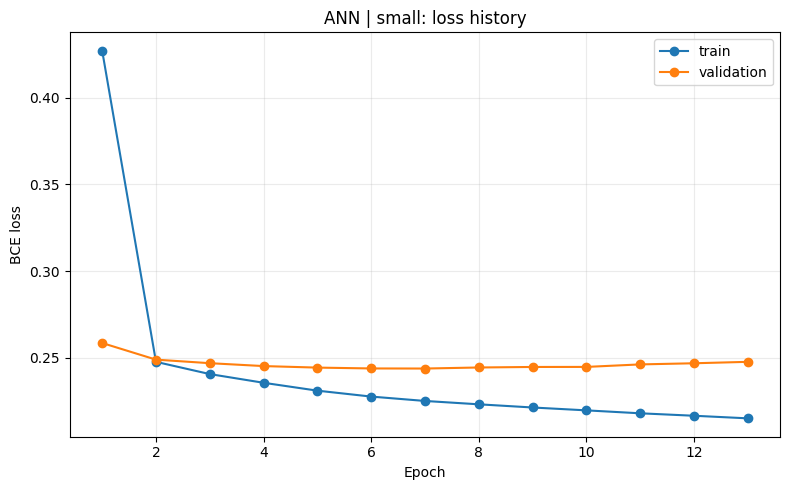

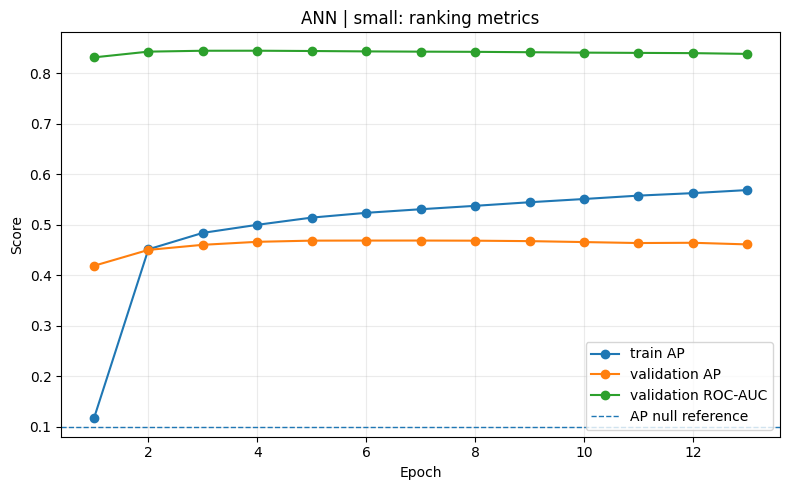

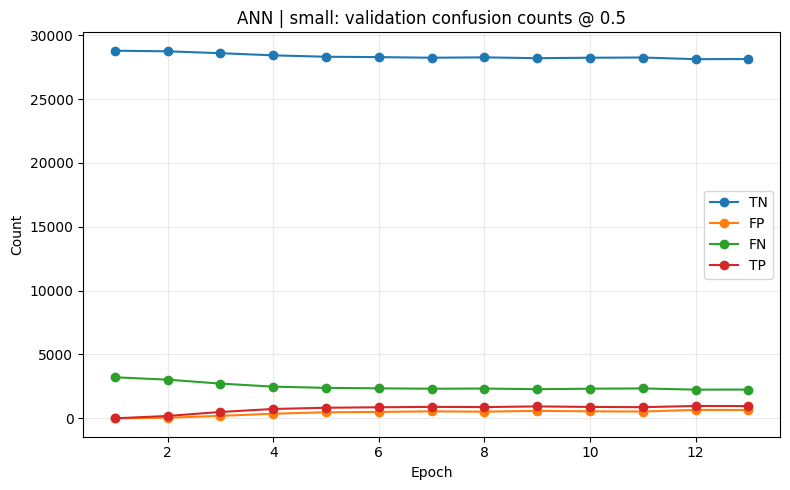

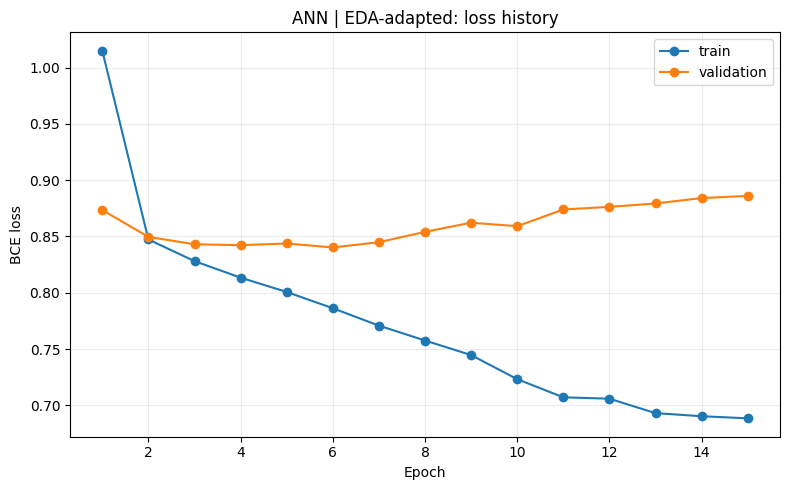

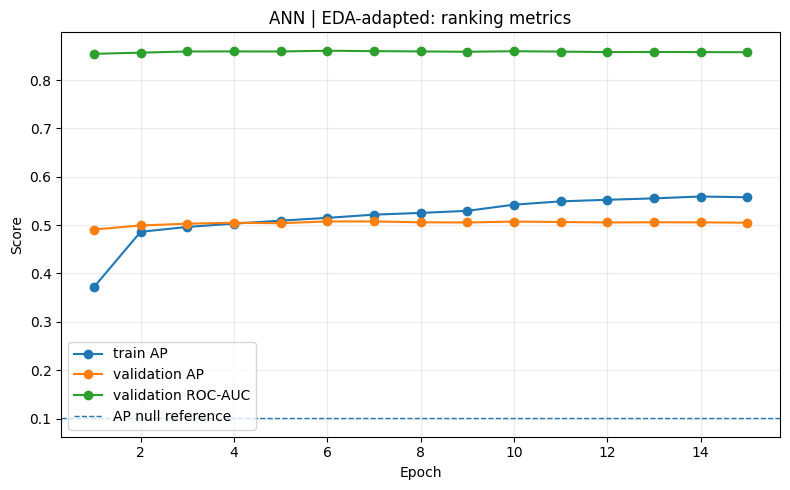

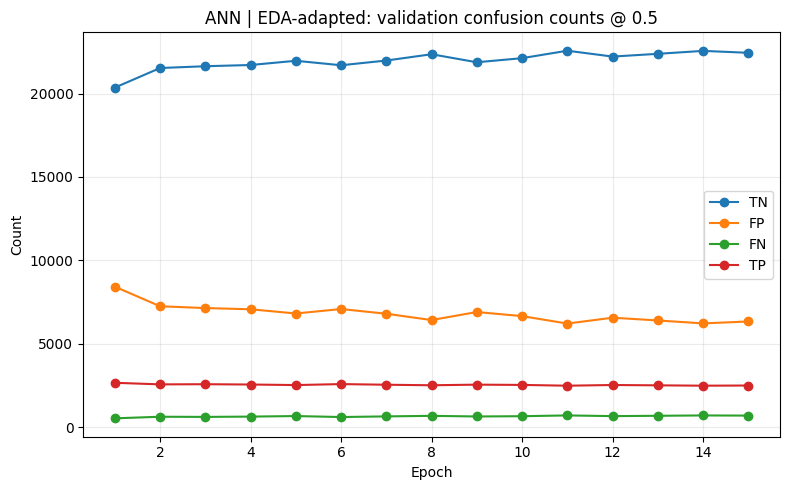

In [14]:
for model_name in ["ANN | small", "ANN | EDA-adapted"]:
    history = HISTORIES[model_name]
    slug = model_name.replace(" | ", "_").replace(" ", "_")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["epoch"], history["train_loss"], marker="o", label="train")
    ax.plot(history["epoch"], history["val_loss"], marker="o", label="validation")
    ax.set_title(f"{model_name}: loss history")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss"); ax.grid(True, alpha=0.25); ax.legend()
    fig.tight_layout(); save_figure(fig, f"{slug}_loss.png"); plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["epoch"], history["train_average_precision"], marker="o", label="train AP")
    ax.plot(history["epoch"], history["val_average_precision"], marker="o", label="validation AP")
    ax.plot(history["epoch"], history["val_roc_auc"], marker="o", label="validation ROC-AUC")
    ax.axhline(y_val.mean(), linestyle="--", linewidth=1, label="AP null reference")
    ax.set_title(f"{model_name}: ranking metrics")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Score"); ax.grid(True, alpha=0.25); ax.legend()
    fig.tight_layout(); save_figure(fig, f"{slug}_ranking_metrics.png"); plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    for label, column in [("TN","val_tn_at_0_5"),("FP","val_fp_at_0_5"),("FN","val_fn_at_0_5"),("TP","val_tp_at_0_5")]:
        ax.plot(history["epoch"], history[column], marker="o", label=label)
    ax.set_title(f"{model_name}: validation confusion counts @ 0.5")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Count"); ax.grid(True, alpha=0.25); ax.legend()
    fig.tight_layout(); save_figure(fig, f"{slug}_confusion_counts.png"); plt.show()


# 9. Validation-Vergleich und Modellwahl

Die vier Konfigurationen werden **vor dem ersten Testzugriff** anhand der Validation Average Precision verglichen. Der Testscore entscheidet somit nicht, welches Modell ausgewaehlt wird.

,model,decision_rule,threshold,roc_auc,average_precision,brier_score,log_loss,accuracy,balanced_accuracy,precision,recall,f1,mcc,specificity,predicted_positive_share,tn,fp,fn,tp
0,NB | standard,fixed_0.5,0.50000,0.88757,0.58052,0.06064,0.21149,0.92047,0.67337,0.70078,0.36412,0.47923,0.46863,0.98263,0.05222,28284,500,2045,1171
1,NB | standard,validation_f1_threshold,0.26833,0.88757,0.58052,0.06064,0.21149,0.90503,0.76008,0.52496,0.57867,0.55051,0.49830,0.94150,0.11078,27100,1684,1355,1861
2,NB | EDA-adapted,fixed_0.5,0.50000,0.88912,0.57965,0.06061,0.21098,0.92009,0.67165,0.69837,0.36070,0.47570,0.46528,0.98259,0.05191,28283,501,2056,1160
3,NB | EDA-adapted,validation_f1_threshold,0.26614,0.88912,0.57965,0.06061,0.21098,0.90700,0.76104,0.53448,0.57836,0.55556,0.50420,0.94372,0.10875,27164,1620,1356,1860
4,ANN | small,fixed_0.5,0.50000,0.84257,0.46862,0.06955,0.24379,0.91041,0.63008,0.62059,0.27923,0.38516,0.37645,0.98093,0.04522,28235,549,2318,898
5,ANN | small,validation_f1_threshold,0.25553,0.84257,0.46862,0.06955,0.24379,0.88519,0.71867,0.43877,0.51026,0.47182,0.40929,0.92708,0.11688,26685,2099,1575,1641
6,ANN | EDA-adapted,fixed_0.5,0.50000,0.85972,0.50763,0.15272,0.46016,0.76662,0.77913,0.27296,0.79478,0.40636,0.36892,0.76348,0.29263,21976,6808,660,2556
7,ANN | EDA-adapted,validation_f1_threshold,0.73405,0.85972,0.50763,0.15272,0.46016,0.88375,0.74521,0.43974,0.57183,0.49716,0.43748,0.91860,0.13069,26441,2343,1377,1839


Selected by validation Average Precision: NB | standard


,model,roc_auc,average_precision,brier_score,balanced_accuracy,precision,recall,f1,threshold
0,NB | standard,0.88757,0.58052,0.06064,0.76008,0.52496,0.57867,0.55051,0.26833
1,NB | EDA-adapted,0.88912,0.57965,0.06061,0.76104,0.53448,0.57836,0.55556,0.26614
2,ANN | EDA-adapted,0.85972,0.50763,0.15272,0.74521,0.43974,0.57183,0.49716,0.73405
3,ANN | small,0.84257,0.46862,0.06955,0.71867,0.43877,0.51026,0.47182,0.25553


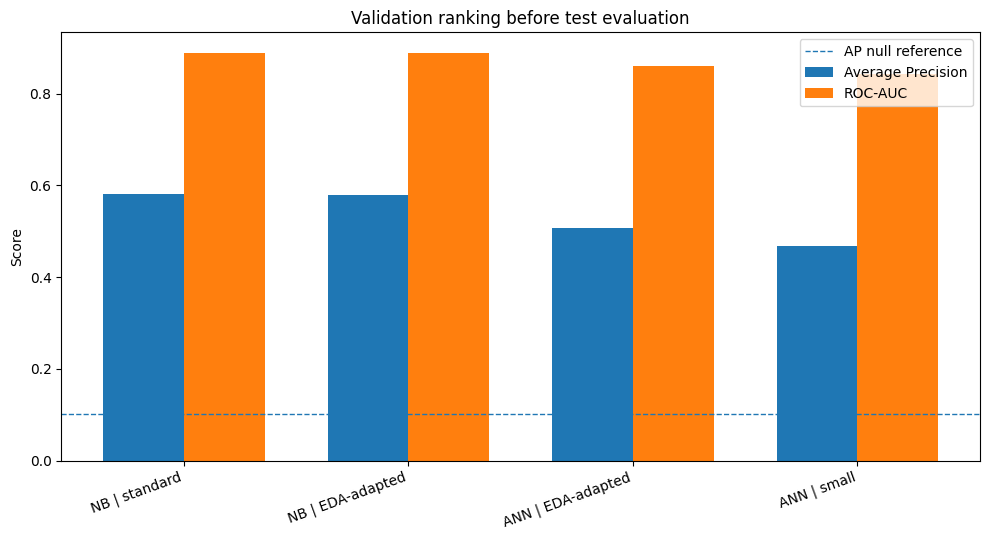

In [15]:
validation_rows = []
for model_name in MODEL_ORDER:
    probs = VAL_PROBS[model_name]
    for rule, threshold in [("fixed_0.5", 0.5), ("validation_f1_threshold", THRESHOLDS[model_name])]:
        validation_rows.append({
            "model": model_name, "decision_rule": rule,
            **compute_metrics(y_val, probs, threshold),
        })
validation_results = pd.DataFrame(validation_rows)
display(validation_results.round(5))

validation_ranking = (
    validation_results[validation_results["decision_rule"] == "validation_f1_threshold"]
    .sort_values("average_precision", ascending=False).reset_index(drop=True)
)
selected_model = str(validation_ranking.iloc[0]["model"])
print("Selected by validation Average Precision:", selected_model)
display(validation_ranking[[
    "model", "roc_auc", "average_precision", "brier_score",
    "balanced_accuracy", "precision", "recall", "f1", "threshold"
]].round(5))
if SAVE_ARTIFACTS:
    validation_results.to_csv(RUN_DIR / "validation_results.csv", index=False)
    pd.DataFrame(MODEL_META).T.to_csv(RUN_DIR / "model_metadata.csv")

ranking_plot = validation_ranking.set_index("model")
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(ranking_plot)); width = 0.36
ax.bar(x - width/2, ranking_plot["average_precision"], width, label="Average Precision")
ax.bar(x + width/2, ranking_plot["roc_auc"], width, label="ROC-AUC")
ax.axhline(y_val.mean(), linestyle="--", linewidth=1, label="AP null reference")
ax.set_xticks(x, ranking_plot.index, rotation=20, ha="right")
ax.set_title("Validation ranking before test evaluation"); ax.set_ylabel("Score"); ax.legend()
fig.tight_layout(); save_figure(fig, "05_validation_model_ranking.png"); plt.show()


# 10. Finale Test-Evaluation

Ab hier wird das Testset erstmals fuer die vier neuen Modellkonfigurationen verwendet. `selected_model` wurde bereits im Validation-Abschnitt festgelegt. Die EDA-Logistic-Regression wird nur als historische Referenz angezeigt.

In [16]:
X_test_standard = standard_scaler.transform(X_test).astype(np.float32)
X_test_quantile = quantile_transformer.transform(X_test).astype(np.float32)

TEST_PROBS["NB | standard"] = nb_standard.predict_proba(X_test)[:, 1]
TEST_PROBS["NB | EDA-adapted"] = nb_adapted.predict_proba(X_test_quantile)[:, 1]

small_test_loader = make_loader(X_test_standard, y_test, shuffle=False, seed=RANDOM_STATE)
_, _, TEST_PROBS["ANN | small"] = evaluate_ann(small_ann, small_test_loader, small_criterion)
adapted_test_loader = make_loader(X_test_quantile, y_test, shuffle=False, seed=RANDOM_STATE)
_, _, TEST_PROBS["ANN | EDA-adapted"] = evaluate_ann(adapted_ann, adapted_test_loader, adapted_criterion)

test_rows = []
for model_name in MODEL_ORDER:
    probs = TEST_PROBS[model_name]
    for rule, threshold in [("fixed_0.5", 0.5), ("validation_f1_threshold", THRESHOLDS[model_name])]:
        test_rows.append({
            "model": model_name,
            "decision_rule": rule,
            "selected_by_validation_ap": model_name == selected_model,
            **compute_metrics(y_test, probs, threshold),
        })
    if SAVE_ARTIFACTS:
        slug = model_name.replace(" | ", "_").replace(" ", "_")
        prediction_frame(idx_test, y_test, probs, THRESHOLDS[model_name]).to_csv(
            PREDICTIONS_DIR / f"{slug}_test.csv", index=False
        )
        prediction_frame(idx_val, y_val, VAL_PROBS[model_name], THRESHOLDS[model_name]).to_csv(
            PREDICTIONS_DIR / f"{slug}_validation.csv", index=False
        )

test_results = pd.DataFrame(test_rows)
if SAVE_ARTIFACTS:
    test_results.to_csv(RUN_DIR / "test_results.csv", index=False)
test_tuned = test_results[test_results["decision_rule"] == "validation_f1_threshold"].copy()
display(test_tuned[[
    "model", "selected_by_validation_ap", "roc_auc", "average_precision", "brier_score",
    "balanced_accuracy", "precision", "recall", "f1", "mcc", "specificity", "threshold"
]].round(5))
print("EDA Logistic Regression reference (same intended first 80:20 split):")
display(pd.Series(EDA_LOGISTIC_REFERENCE).to_frame("EDA reference").round(5))


,model,selected_by_validation_ap,roc_auc,average_precision,brier_score,balanced_accuracy,precision,recall,f1,mcc,specificity,threshold
1,NB | standard,True,0.88812,0.57548,0.06105,0.75250,0.53037,0.56045,0.54499,0.49283,0.94455,0.26833
3,NB | EDA-adapted,False,0.88791,0.57344,0.06119,0.75315,0.53117,0.56169,0.54600,0.49394,0.94461,0.26614
5,ANN | small,False,0.84638,0.46658,0.06970,0.71215,0.44107,0.49428,0.46616,0.40353,0.93002,0.25553
7,ANN | EDA-adapted,False,0.86078,0.50301,0.15045,0.73618,0.43449,0.55274,0.48653,0.42531,0.91962,0.73405


EDA Logistic Regression reference (same intended first 80:20 split):


,EDA reference
roc_auc,0.8599
average_precision,0.5004
balanced_accuracy_at_0_5,0.7795
recall_at_0_5,0.7749
precision_at_0_5,0.2863
f1_at_0_5,0.4181


## 10.1 ROC- und Precision-Recall-Kurven

Bei dieser Klassenimbalance ist die PR-Kurve besonders wichtig: ihre horizontale Nullreferenz entspricht dem Positivanteil im Testset.

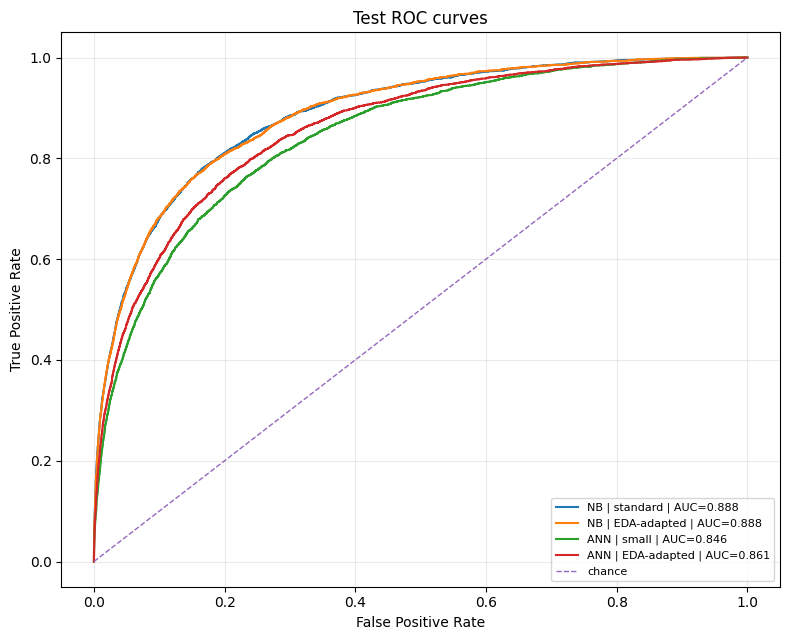

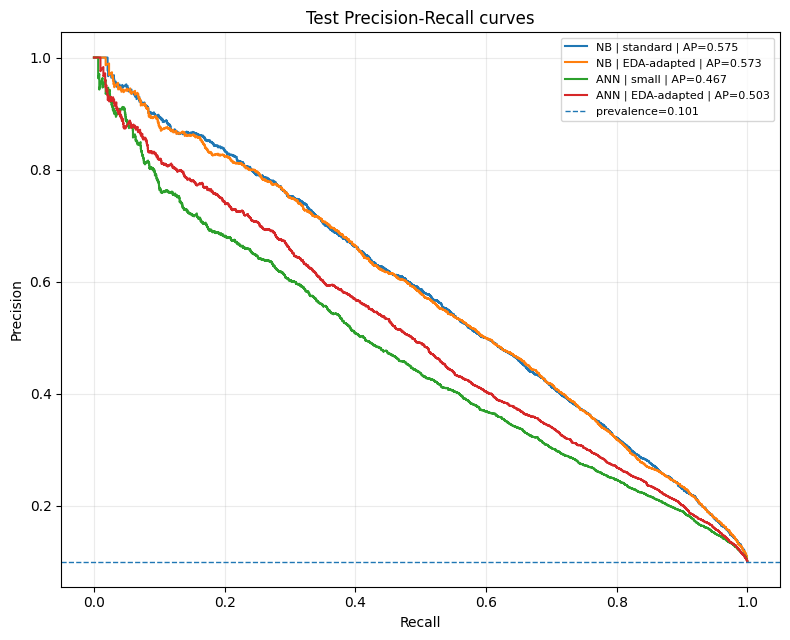

In [17]:
fig, ax = plt.subplots(figsize=(8, 6.5))
for model_name in MODEL_ORDER:
    probs = TEST_PROBS[model_name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f"{model_name} | AUC={roc_auc_score(y_test, probs):.3f}")
ax.plot([0,1],[0,1], "--", linewidth=1, label="chance")
ax.set_title("Test ROC curves"); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.grid(True, alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, "06_test_roc_all_models.png"); plt.show()

fig, ax = plt.subplots(figsize=(8, 6.5))
for model_name in MODEL_ORDER:
    probs = TEST_PROBS[model_name]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax.plot(recall, precision, label=f"{model_name} | AP={average_precision_score(y_test, probs):.3f}")
ax.axhline(y_test.mean(), linestyle="--", linewidth=1, label=f"prevalence={y_test.mean():.3f}")
ax.set_title("Test Precision-Recall curves"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.grid(True, alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, "07_test_pr_all_models.png"); plt.show()


## 10.2 Confusion Matrices am Validation-Threshold

Der verwendete Threshold stammt ausschliesslich aus Validation. Angezeigt werden absolute Counts und der jeweilige Zeilenanteil innerhalb der wahren Klasse.

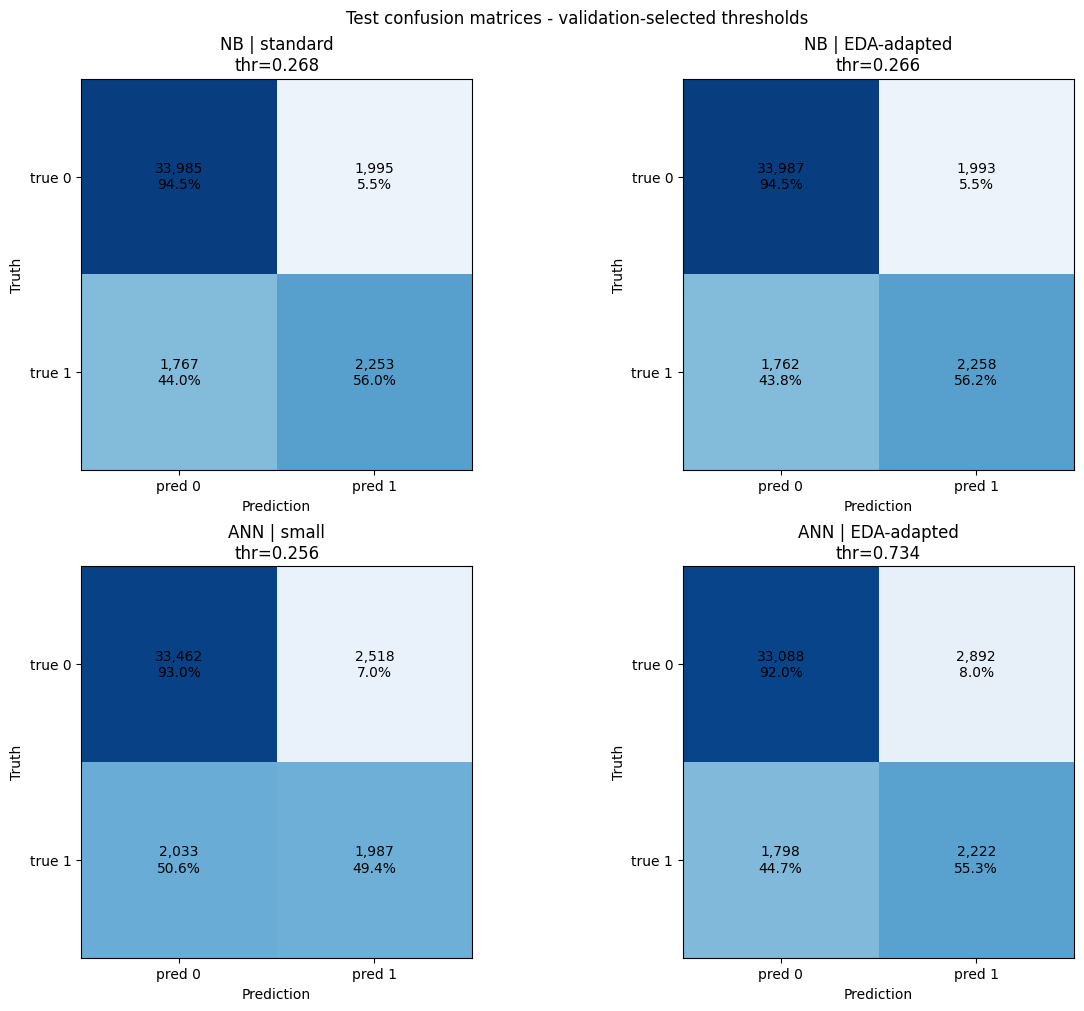

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, model_name in zip(axes.flat, MODEL_ORDER):
    threshold = THRESHOLDS[model_name]
    pred = (TEST_PROBS[model_name] >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0,1])
    row_den = cm.sum(axis=1, keepdims=True)
    normalized = np.divide(cm, row_den, out=np.zeros_like(cm, dtype=float), where=row_den > 0)
    ax.imshow(normalized, vmin=0, vmax=1, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}\n{normalized[i,j]:.1%}", ha="center", va="center")
    ax.set_xticks([0,1],["pred 0","pred 1"]); ax.set_yticks([0,1],["true 0","true 1"])
    ax.set_title(f"{model_name}\nthr={threshold:.3f}"); ax.set_xlabel("Prediction"); ax.set_ylabel("Truth")
fig.suptitle("Test confusion matrices - validation-selected thresholds")
save_figure(fig, "08_test_confusion_matrices.png"); plt.show()


## 10.3 Threshold-Verhalten auf Validation

Dieser Plot macht sichtbar, warum ein Betriebs-Threshold gewaehlt wurde. Der Testdatensatz wird fuer diese Entscheidung nicht verwendet.

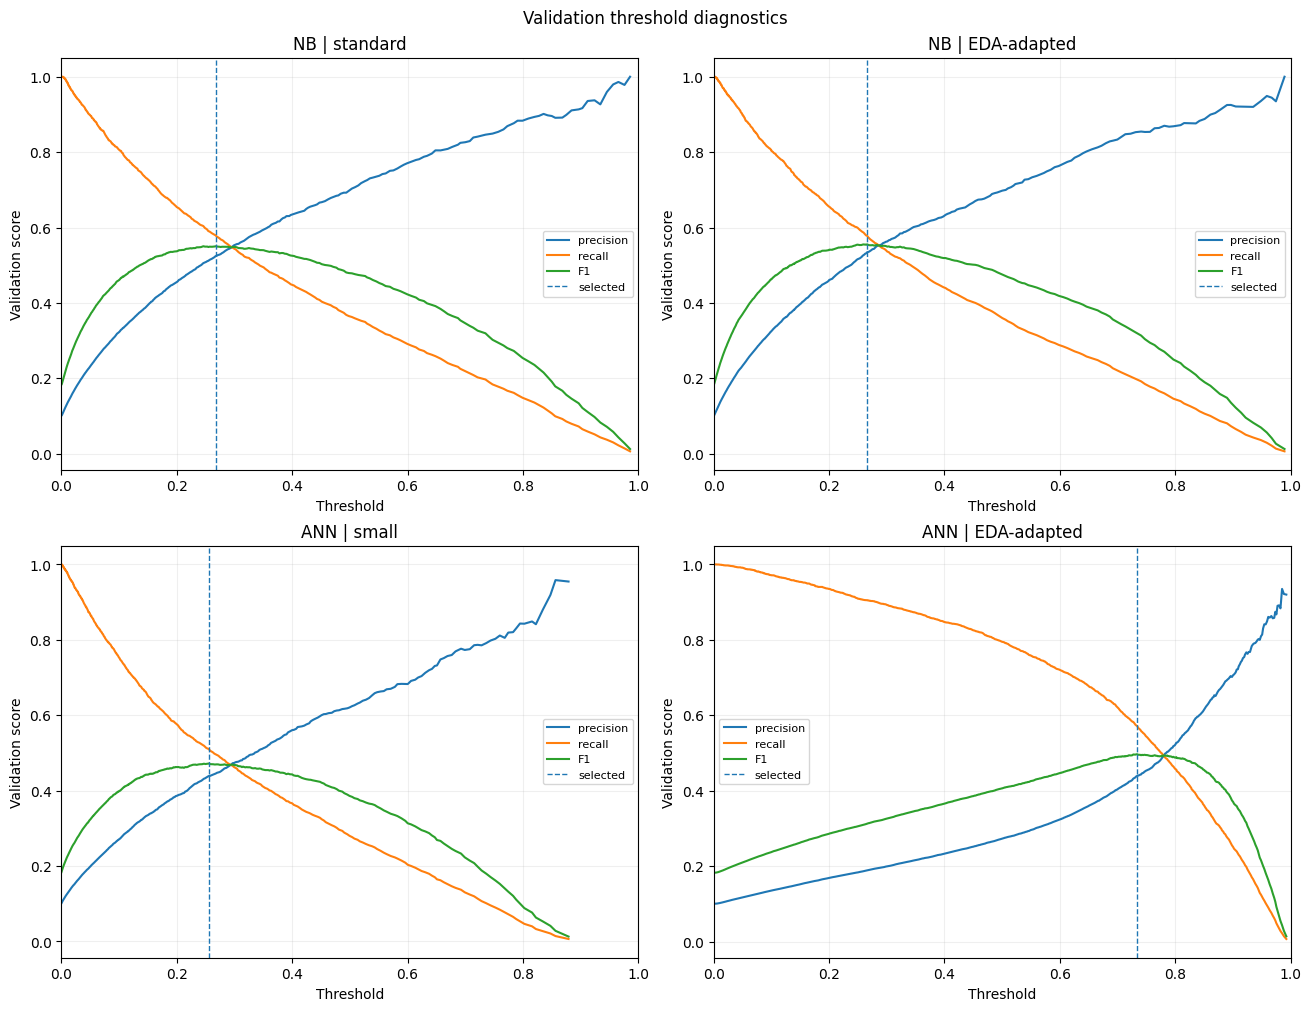

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for ax, model_name in zip(axes.flat, MODEL_ORDER):
    curve = THRESHOLD_CURVES[model_name]
    if len(curve) > 1200:
        curve = curve.iloc[::max(1, len(curve)//1200)]
    ax.plot(curve["threshold"], curve["precision"], label="precision")
    ax.plot(curve["threshold"], curve["recall"], label="recall")
    ax.plot(curve["threshold"], curve["f1"], label="F1")
    ax.axvline(THRESHOLDS[model_name], linestyle="--", linewidth=1, label="selected")
    ax.set_title(model_name); ax.set_xlabel("Threshold"); ax.set_ylabel("Validation score")
    ax.set_xlim(0,1); ax.grid(True, alpha=0.2); ax.legend(fontsize=8)
fig.suptitle("Validation threshold diagnostics")
save_figure(fig, "09_validation_threshold_diagnostics.png"); plt.show()


## 10.4 Kalibrierung und Wahrscheinlichkeitsverteilungen

ROC-AUC/AP beurteilen Ranking, nicht die absolute Guete der Wahrscheinlichkeiten. Daher werden Brier Score, Calibration Curves und die Verteilungen der vorhergesagten Positivwahrscheinlichkeit zusaetzlich berichtet.

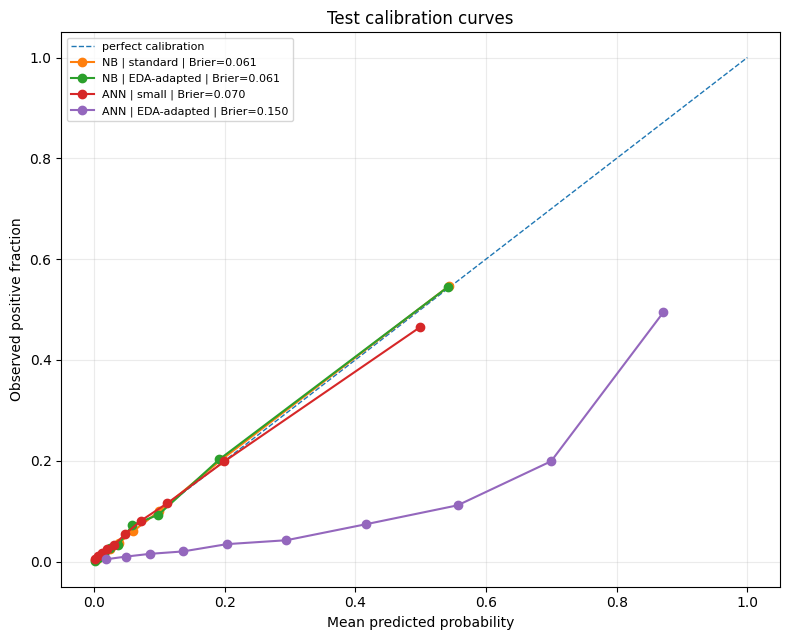

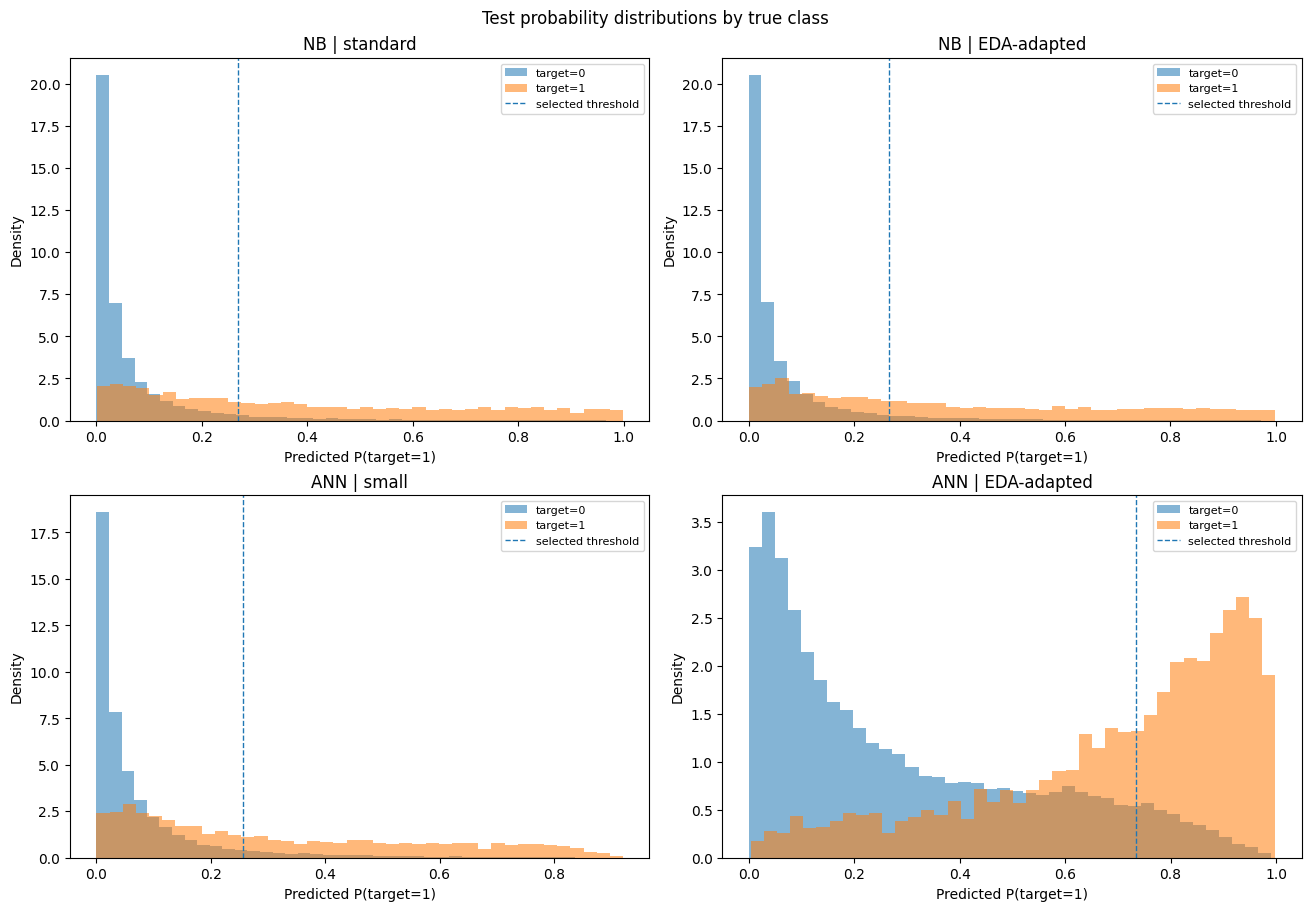

In [20]:
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.plot([0,1],[0,1], "--", linewidth=1, label="perfect calibration")
for model_name in MODEL_ORDER:
    fraction_positive, mean_predicted = calibration_curve(
        y_test, TEST_PROBS[model_name], n_bins=10, strategy="quantile"
    )
    brier = brier_score_loss(y_test, TEST_PROBS[model_name])
    ax.plot(mean_predicted, fraction_positive, marker="o", label=f"{model_name} | Brier={brier:.3f}")
ax.set_title("Test calibration curves"); ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive fraction"); ax.grid(True, alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, "10_test_calibration.png"); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, model_name in zip(axes.flat, MODEL_ORDER):
    probs = TEST_PROBS[model_name]
    ax.hist(probs[y_test==0], bins=40, alpha=0.55, density=True, label="target=0")
    ax.hist(probs[y_test==1], bins=40, alpha=0.55, density=True, label="target=1")
    ax.axvline(THRESHOLDS[model_name], linestyle="--", linewidth=1, label="selected threshold")
    ax.set_title(model_name); ax.set_xlabel("Predicted P(target=1)"); ax.set_ylabel("Density"); ax.legend(fontsize=8)
fig.suptitle("Test probability distributions by true class")
save_figure(fig, "11_test_probability_distributions.png"); plt.show()


## 10.5 Kompakter Modellvergleich

Die erste Grafik zeigt die schwellenwertunabhaengigen Ranking-Metriken. Die zweite zeigt den konkreten Betriebszustand am auf Validation gewaehlten Threshold.

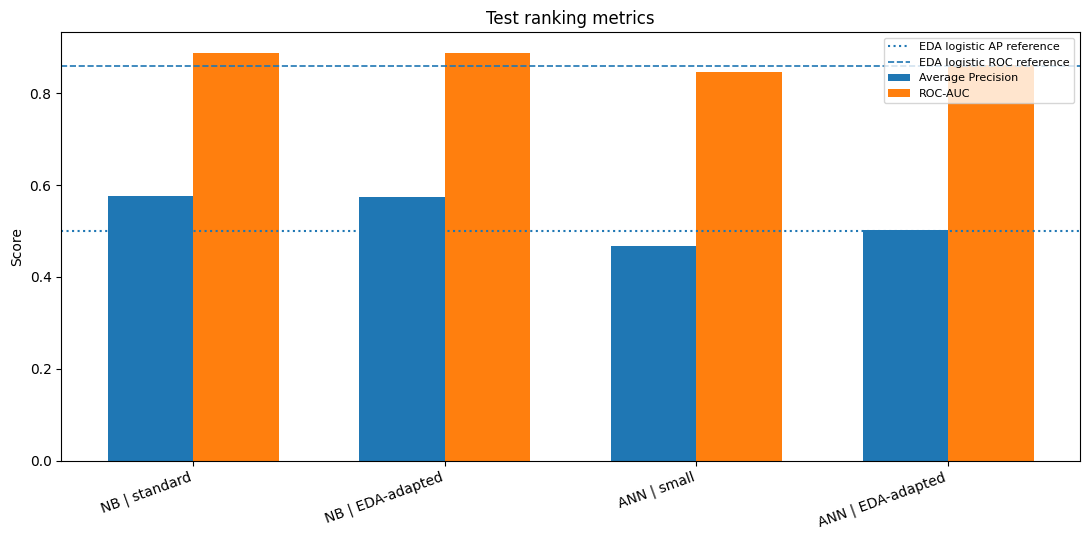

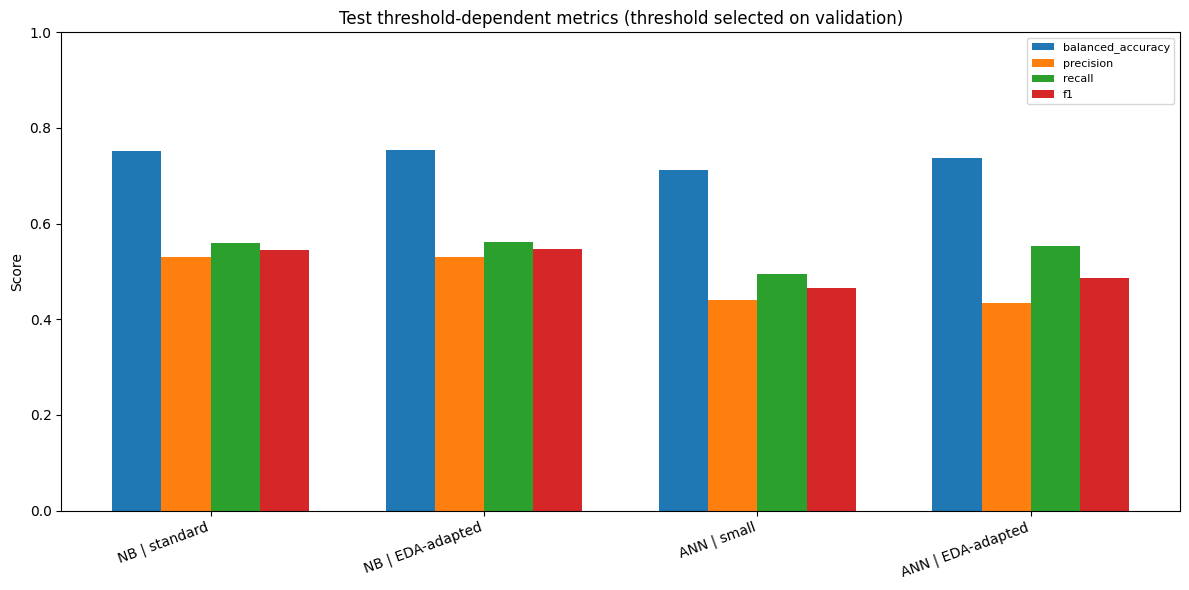

In [21]:
plot_df = test_tuned.set_index("model").loc[MODEL_ORDER]
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(plot_df)); width = 0.34
ax.bar(x-width/2, plot_df["average_precision"], width, label="Average Precision")
ax.bar(x+width/2, plot_df["roc_auc"], width, label="ROC-AUC")
ax.axhline(EDA_LOGISTIC_REFERENCE["average_precision"], linestyle=":", linewidth=1.5, label="EDA logistic AP reference")
ax.axhline(EDA_LOGISTIC_REFERENCE["roc_auc"], linestyle="--", linewidth=1.2, label="EDA logistic ROC reference")
ax.set_xticks(x, plot_df.index, rotation=20, ha="right"); ax.set_title("Test ranking metrics"); ax.set_ylabel("Score")
ax.legend(fontsize=8); fig.tight_layout(); save_figure(fig, "12_test_ranking_metric_comparison.png"); plt.show()

metrics_to_plot = ["balanced_accuracy", "precision", "recall", "f1"]
fig, ax = plt.subplots(figsize=(12, 6)); width = 0.18; x = np.arange(len(plot_df))
for offset, metric in enumerate(metrics_to_plot):
    ax.bar(x + (offset-1.5)*width, plot_df[metric], width, label=metric)
ax.set_xticks(x, plot_df.index, rotation=20, ha="right")
ax.set_title("Test threshold-dependent metrics (threshold selected on validation)")
ax.set_ylabel("Score"); ax.set_ylim(0,1); ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, "13_test_threshold_metric_comparison.png"); plt.show()


# 11. Unsicherheit: Bootstrap-Konfidenzintervalle

Ein einzelner Testscore ist eine Stichprobenschaetzung. Fuer ROC-AUC und Average Precision werden daher nichtparametrische 95%-Bootstrap-Intervalle berechnet. Diese Analyse aendert keine Modellentscheidung; sie quantifiziert nur die Unsicherheit der bereits berichteten Testwerte.

,model,metric,estimate,ci_low,ci_high,bootstrap_sd,n_bootstrap
0,NB | standard,average_precision,0.57548,0.56150,0.59057,0.00775,200
1,NB | standard,roc_auc,0.88812,0.88384,0.89331,0.00252,200
2,NB | EDA-adapted,average_precision,0.57344,0.56007,0.58840,0.00771,200
3,NB | EDA-adapted,roc_auc,0.88791,0.88336,0.89331,0.00256,200
4,ANN | small,average_precision,0.46658,0.45201,0.48114,0.00743,200
5,ANN | small,roc_auc,0.84638,0.84116,0.85216,0.00278,200
6,ANN | EDA-adapted,average_precision,0.50301,0.48859,0.51805,0.00769,200
7,ANN | EDA-adapted,roc_auc,0.86078,0.85561,0.86700,0.00281,200


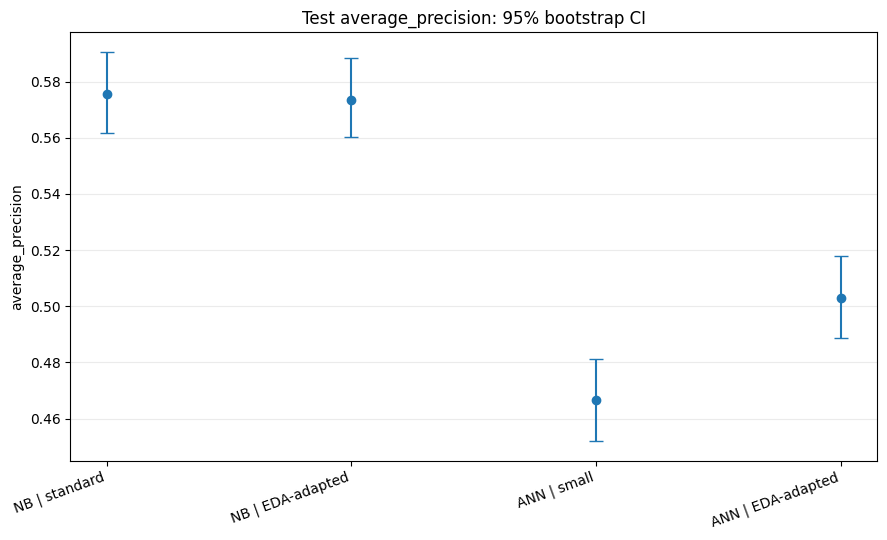

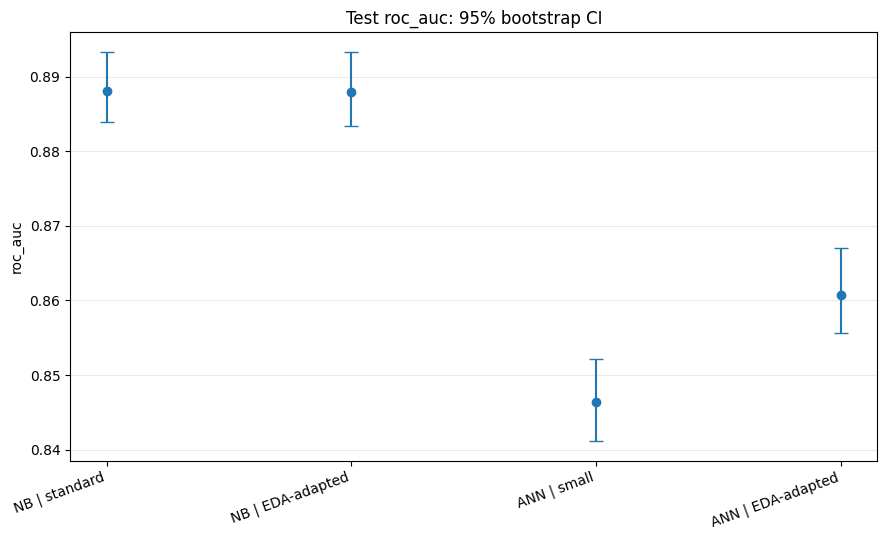

In [22]:
def bootstrap_score_ci(y_true, probabilities, metric, reps=200, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    n = len(y_true)
    values = []
    for _ in range(reps):
        sample_idx = rng.integers(0, n, size=n)
        y_boot = y_true[sample_idx]
        if np.unique(y_boot).size < 2:
            continue
        p_boot = probabilities[sample_idx]
        if metric == "roc_auc":
            values.append(roc_auc_score(y_boot, p_boot))
        elif metric == "average_precision":
            values.append(average_precision_score(y_boot, p_boot))
        else:
            raise ValueError(metric)
    values = np.asarray(values, dtype=float)
    estimate = roc_auc_score(y_true, probabilities) if metric == "roc_auc" else average_precision_score(y_true, probabilities)
    return {
        "estimate": float(estimate),
        "ci_low": float(np.percentile(values, 2.5)),
        "ci_high": float(np.percentile(values, 97.5)),
        "bootstrap_sd": float(values.std(ddof=1)),
        "n_bootstrap": len(values),
    }

bootstrap_rows = []
if RUN_BOOTSTRAP:
    for model_name in MODEL_ORDER:
        for metric in ["average_precision", "roc_auc"]:
            bootstrap_rows.append({
                "model": model_name, "metric": metric,
                **bootstrap_score_ci(y_test, TEST_PROBS[model_name], metric, reps=N_BOOTSTRAP, seed=RANDOM_STATE),
            })
    bootstrap_results = pd.DataFrame(bootstrap_rows)
    display(bootstrap_results.round(5))
    if SAVE_ARTIFACTS:
        bootstrap_results.to_csv(RUN_DIR / "bootstrap_test_ci.csv", index=False)

    for metric in ["average_precision", "roc_auc"]:
        part = bootstrap_results[bootstrap_results["metric"] == metric].set_index("model").loc[MODEL_ORDER]
        fig, ax = plt.subplots(figsize=(9, 5.5))
        x = np.arange(len(part))
        lower = part["estimate"] - part["ci_low"]
        upper = part["ci_high"] - part["estimate"]
        ax.errorbar(x, part["estimate"], yerr=np.vstack([lower, upper]), fmt="o", capsize=5)
        ax.set_xticks(x, part.index, rotation=20, ha="right")
        ax.set_title(f"Test {metric}: 95% bootstrap CI"); ax.set_ylabel(metric); ax.grid(True, axis="y", alpha=0.25)
        fig.tight_layout(); save_figure(fig, f"14_bootstrap_{metric}.png"); plt.show()
else:
    bootstrap_results = pd.DataFrame()
    print("Bootstrap disabled by configuration.")


## 11.1 Fehleranalyse: sicherste Fehlklassifikationen

Die Features sind anonymisiert; eine fachliche Kundeninterpretation ist daher nicht moeglich. Trotzdem werden die sichersten False Positives und False Negatives inklusive Original-Zeilenindex gespeichert. Diese Faelle koennen spaeter gezielt in der EDA nachuntersucht werden.

In [23]:
error_tables = []
for model_name in MODEL_ORDER:
    threshold = THRESHOLDS[model_name]
    probs = TEST_PROBS[model_name]
    pred = (probs >= threshold).astype(int)
    frame = pd.DataFrame({
        "row_index": idx_test, "true_label": y_test,
        "prediction": pred, "probability_target_1": probs,
    })
    fp = frame[(frame.true_label==0) & (frame.prediction==1)].nlargest(10, "probability_target_1").copy()
    fp["error_type"] = "false_positive"
    fn = frame[(frame.true_label==1) & (frame.prediction==0)].nsmallest(10, "probability_target_1").copy()
    fn["error_type"] = "false_negative"
    errors = pd.concat([fp, fn], ignore_index=True)
    errors.insert(0, "model", model_name)
    error_tables.append(errors)
error_analysis = pd.concat(error_tables, ignore_index=True)
display(error_analysis.groupby(["model","error_type"])["probability_target_1"].agg(["count","min","median","max"]).round(4))
if SAVE_ARTIFACTS:
    error_analysis.to_csv(RUN_DIR / "high_confidence_errors.csv", index=False)


count     min  median     max
model             error_type                                   
ANN | EDA-adapted false_negative     10  0.0044  0.0151  0.0205
                  false_positive     10  0.9819  0.9864  0.9909
ANN | small       false_negative     10  0.0002  0.0014  0.0023
                  false_positive     10  0.8312  0.8417  0.8805
NB | EDA-adapted  false_negative     10  0.0009  0.0033  0.0041
                  false_positive     10  0.9335  0.9516  0.9710
NB | standard     false_negative     10  0.0007  0.0029  0.0039
                  false_positive     10  0.9315  0.9512  0.9654

## 11.2 Optionale ANN-Seed-Stabilitaet

Neuronale Netze besitzen Optimierungsvarianz. Fuer die finale Abgabe kann `RUN_ANN_SEED_STABILITY=True` gesetzt werden. Dann werden beide ANN-Architekturen mit drei Seeds auf identischen Splits neu trainiert und **nur auf Validation** verglichen. Der Block ist standardmaessig aus Rechenzeitgruenden deaktiviert.

In [24]:
seed_stability_rows = []
if RUN_ANN_SEED_STABILITY:
    stability_specs = [
        ("ANN | small", lambda: SmallANN(len(feature_columns)), X_train_standard, X_val_standard,
         dict(epochs=EPOCHS_SMALL, patience=PATIENCE_SMALL, learning_rate=LEARNING_RATE_SMALL,
              weighted_loss=False, optimizer_name="adam", weight_decay=0.0, monitor="val_loss")),
        ("ANN | EDA-adapted", lambda: EDAAdaptedANN(len(feature_columns)), X_train_adapted, X_val_adapted,
         dict(epochs=EPOCHS_ADAPTED, patience=PATIENCE_ADAPTED, learning_rate=LEARNING_RATE_ADAPTED,
              weighted_loss=True, optimizer_name="adamw", weight_decay=WEIGHT_DECAY_ADAPTED, monitor="val_ap")),
    ]
    for base_name, factory, Xtr, Xva, kwargs in stability_specs:
        for seed in ANN_STABILITY_SEEDS:
            model, _, meta = fit_ann(factory(), f"{base_name} seed {seed}", Xtr, Xva, seed=seed, **kwargs)
            loader = make_loader(Xva, y_val, shuffle=False, seed=seed)
            criterion = nn.BCEWithLogitsLoss()
            _, _, prob = evaluate_ann(model, loader, criterion)
            seed_stability_rows.append({
                "model": base_name, "seed": seed,
                "validation_average_precision": average_precision_score(y_val, prob),
                "validation_roc_auc": roc_auc_score(y_val, prob),
                "best_epoch": meta["best_epoch"],
            })
    ann_seed_stability = pd.DataFrame(seed_stability_rows)
    display(ann_seed_stability)
    display(ann_seed_stability.groupby("model")[["validation_average_precision","validation_roc_auc"]].agg(["mean","std"]).round(5))
    if SAVE_ARTIFACTS:
        ann_seed_stability.to_csv(RUN_DIR / "ann_seed_stability.csv", index=False)
else:
    print("ANN seed stability disabled. Enable for the final robustness check if compute time permits.")


ANN seed stability disabled. Enable for the final robustness check if compute time permits.


# 12. Automatische Zusammenfassung

Die Kernaussagen werden aus den tatsaechlich berechneten Tabellen erzeugt. Eine EDA-adaptierte Variante ist nur dann ueberzeugend, wenn ihr Validation-Gewinn plausibel ist und auf Test nicht deutlich zusammenbricht.

In [25]:
tuned_lookup = test_tuned.set_index("model")
val_lookup = validation_ranking.set_index("model")
nb_delta_val = val_lookup.loc["NB | EDA-adapted", "average_precision"] - val_lookup.loc["NB | standard", "average_precision"]
ann_delta_val = val_lookup.loc["ANN | EDA-adapted", "average_precision"] - val_lookup.loc["ANN | small", "average_precision"]
nb_delta_test = tuned_lookup.loc["NB | EDA-adapted", "average_precision"] - tuned_lookup.loc["NB | standard", "average_precision"]
ann_delta_test = tuned_lookup.loc["ANN | EDA-adapted", "average_precision"] - tuned_lookup.loc["ANN | small", "average_precision"]
selected_test = tuned_lookup.loc[selected_model]

summary_lines = [
    "FINAL REPORT", "============",
    f"Model selected BEFORE test inspection by validation AP: {selected_model}",
    f"Selected model validation AP: {val_lookup.loc[selected_model, 'average_precision']:.4f}",
    f"Selected model test AP: {selected_test['average_precision']:.4f}",
    f"Selected model test ROC-AUC: {selected_test['roc_auc']:.4f}",
    f"Selected model test F1 at validation threshold ({selected_test['threshold']:.4f}): {selected_test['f1']:.4f}",
    f"NB adapted - standard AP delta: validation {nb_delta_val:+.4f}, test {nb_delta_test:+.4f}",
    f"ANN adapted - small AP delta: validation {ann_delta_val:+.4f}, test {ann_delta_test:+.4f}",
    f"EDA logistic reference: AP={EDA_LOGISTIC_REFERENCE['average_precision']:.4f}, ROC-AUC={EDA_LOGISTIC_REFERENCE['roc_auc']:.4f}",
]
print("\n".join(summary_lines))
print("\nInterpretation:")
print("- Positive adapted-standard delta supports the corresponding EDA-driven modification.")
print("- A validation gain that reverses strongly on test indicates model-selection noise/overfitting.")
print("- AP null reference is the test positive prevalence:", f"{y_test.mean():.4f}")
print("- ROC/AP assess ranking; Brier/calibration assess probability quality; F1/precision/recall depend on threshold.")
if SAVE_ARTIFACTS:
    (RUN_DIR / "summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")


FINAL REPORT
Model selected BEFORE test inspection by validation AP: NB | standard
Selected model validation AP: 0.5805
Selected model test AP: 0.5755
Selected model test ROC-AUC: 0.8881
Selected model test F1 at validation threshold (0.2683): 0.5450
NB adapted - standard AP delta: validation -0.0009, test -0.0020
ANN adapted - small AP delta: validation +0.0390, test +0.0364
EDA logistic reference: AP=0.5004, ROC-AUC=0.8599

Interpretation:
- Positive adapted-standard delta supports the corresponding EDA-driven modification.
- A validation gain that reverses strongly on test indicates model-selection noise/overfitting.
- AP null reference is the test positive prevalence: 0.1005
- ROC/AP assess ranking; Brier/calibration assess probability quality; F1/precision/recall depend on threshold.


## 13. Konfiguration speichern und Run abschliessen

`config.json` dokumentiert Datensatz, Softwareversionen, Splitlogik, Modellmetadaten, Thresholds und die EDA-Referenz. `results.csv` ist die kompakte Tabelle fuer Portfolio/Reporting.

In [26]:
config_payload = {
    "data_path": str(DATA_PATH),
    "smoke_test": SMOKE_TEST,
    "target": TARGET,
    "n_rows": int(len(df)),
    "n_features": int(len(feature_columns)),
    "positive_share": float(y.mean()),
    "random_state": RANDOM_STATE,
    "splits": {
        "train_n": int(len(idx_train)), "validation_n": int(len(idx_val)), "test_n": int(len(idx_test)),
        "test_size": TEST_SIZE, "validation_fraction_of_development": VAL_FRACTION_OF_DEV,
    },
    "selection": {
        "primary_model_ranking_metric": "validation average precision",
        "threshold_objective": THRESHOLD_OBJECTIVE,
        "selected_model": selected_model,
        "thresholds": {key: float(value) for key, value in THRESHOLDS.items()},
    },
    "model_metadata": MODEL_META,
    "eda_logistic_reference": EDA_LOGISTIC_REFERENCE,
    "versions": {
        "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__, "torch": torch.__version__,
    },
    "device": str(DEVICE),
    "bootstrap_repetitions": N_BOOTSTRAP if RUN_BOOTSTRAP else 0,
}
save_json(config_payload, RUN_DIR / "config.json")
if SAVE_ARTIFACTS:
    final_report_table = test_tuned[[
        "model", "selected_by_validation_ap", "roc_auc", "average_precision", "brier_score",
        "balanced_accuracy", "precision", "recall", "f1", "mcc", "specificity", "threshold"
    ]].copy()
    final_report_table.to_csv(RUN_DIR / "results.csv", index=False)
print("Run complete.")
print("Artifacts:", RUN_DIR)
if SAVE_ARTIFACTS:
    for path in sorted(RUN_DIR.rglob("*")):
        if path.is_file():
            print(" -", path.relative_to(RUN_DIR))


Run complete.
Artifacts: C:\Users\Cypsa\Desktop\UNI\UNI JLU DS\ADA_Project\Cyp\ML\runs\20260815_030409_NB_ANN
 - bootstrap_test_ci.csv
 - checkpoints\ANN_EDA-adapted_best.pt
 - checkpoints\ANN_EDA-adapted_last.pt
 - checkpoints\ANN_small_best.pt
 - checkpoints\ANN_small_last.pt
 - config.json
 - high_confidence_errors.csv
 - histories\ANN_EDA-adapted.csv
 - histories\ANN_small.csv
 - model_metadata.csv
 - models\ann_adapted_quantile_transformer.joblib
 - models\ann_small_standard_scaler.joblib
 - models\gaussian_nb_eda_adapted.joblib
 - models\gaussian_nb_standard.joblib
 - plots\00_class_distribution.png
 - plots\01_split_class_counts.png
 - plots\02_nb_var_smoothing_search.png
 - plots\03_nb_validation_roc.png
 - plots\04_nb_validation_pr.png
 - plots\05_validation_model_ranking.png
 - plots\06_test_roc_all_models.png
 - plots\07_test_pr_all_models.png
 - plots\08_test_confusion_matrices.png
 - plots\09_validation_threshold_diagnostics.png
 - plots\10_test_calibration.png
 - plots\11

# 14. Methodische Einordnung fuer Portfolio und Logbuch

Nach dem Lauf sollte nicht nur der beste Score dokumentiert werden, sondern die **Entscheidungskette**:

1. EDA: starke Imbalance, viele schwache Features, keine starke lineare Redundanz, geringe PCA-Komprimierbarkeit.
2. Daraus: GaussianNB als einfache probabilistische Baseline und kleines MLP auf allen Features.
3. EDA-Hypothesen: robuste Marginaltransformation; beim ANN zusaetzlich Imbalance-Gewichtung und Regularisierung.
4. Validation entscheidet NB-Hyperparameter, Thresholds und Modellranking; Test bleibt bis dahin unberuehrt.
5. Reporting kombiniert AP/ROC-AUC, Calibration/Brier sowie Precision/Recall/F1/Balanced Accuracy.
6. Bootstrap-CIs quantifizieren Testunsicherheit; optionale Seed-Runs pruefen ANN-Optimierungsstabilitaet.

Damit ist auch ein Ergebnis wie "das einfache GaussianNB bleibt konkurrenzfaehig" fachlich wertvoll. Die Komplexitaet eines Modells ist kein Qualitaetskriterium; entscheidend sind robuste, nachvollziehbare Verbesserungen.